<div style="box-sizing:border-box;width:100%;border:2px solid #cbd5e1;background:#fff;border-radius:12px;padding:6px 26px 22px 26px;font-family:-apple-system,Segoe UI,Roboto,Helvetica,Arial,sans-serif;">
  <div style="border:1px solid #e2e8f0;border-left:7px solid #1f3a5f;background:#f8fafc;border-radius:10px;padding:24px 28px;margin:18px 0 20px 0;">
    <p style="margin:0 0 8px 0;font-size:13px;font-weight:700;letter-spacing:.5px;color:#1f3a5f;text-transform:uppercase;">Informe Técnico · Sumativa 2</p>
    <h1 style="margin:0 0 8px 0;font-size:27px;line-height:1.25;color:#1f2937;font-weight:700;">Validación, Simulación y Métodos de Remuestreo</h1>
    <p style="margin:0;font-size:15px;line-height:1.6;color:#334155;">Proyecto ABP · Calidad del Aire en Santiago · Red SINCA 2022–2025</p>
  </div>
  <table style="width:100%;border-collapse:collapse;font-size:13.5px;color:#334155;">
    <tr><td style="padding:6px 0;width:170px;border-bottom:1px solid #eef2f7;"><b style="color:#1f3a5f;">Asignatura</b></td><td style="padding:6px 0;border-bottom:1px solid #eef2f7;">MCDI501 — Estadística Computacional para la Toma de Decisiones · UNAB</td></tr>
    <tr><td style="padding:6px 0;border-bottom:1px solid #eef2f7;"><b style="color:#1f3a5f;">Producto</b></td><td style="padding:6px 0;border-bottom:1px solid #eef2f7;">Sumativa 2 — Remuestreo, validación, Monte Carlo y robustez</td></tr>
    <tr><td style="padding:6px 0;border-bottom:1px solid #eef2f7;"><b style="color:#1f3a5f;">Continuidad</b></td><td style="padding:6px 0;border-bottom:1px solid #eef2f7;">Basado en <code>01_analisis_estadistico_diario.ipynb</code></td></tr>
    <tr><td style="padding:6px 0;"><b style="color:#1f3a5f;">Integrantes</b></td><td style="padding:6px 0;">Rodrigo Chinchón Ayala · Pablo Villalobos González · Sergio Fernández Almonacid</td></tr>
  </table>
</div>

<div style="border:1px solid #e2e8f0;background:#fff;border-radius:12px;padding:8px 24px 16px 24px;font-family:-apple-system,Segoe UI,Roboto,Helvetica,Arial,sans-serif;">
<h2 style="color:#1f2937;">📑 Tabla de contenidos</h2>
<ol style="font-size:15px;line-height:1.8;color:#1f2937;">
<li>Configuración del entorno y trazabilidad</li><li>Carga del dataset consolidado de S1</li><li>Recuperación de resultados base de S1</li><li>Bootstrap de parámetros estimados + interpretación</li><li>Permutación</li><li>Estabilidad de correlaciones</li><li>Monte Carlo</li><li>Robustez</li><li>Reporte validado para S3</li><li>Visualizaciones premium e interpretaciones HTML</li><li>Bibliografía</li>
</ol></div>

<div style="background:#ffffff;border:1px solid #dbe5ef;border-left:7px solid #2563eb;border-radius:14px;padding:22px 26px;margin:18px 0;font-family:Arial,Helvetica,sans-serif;color:#0f172a;line-height:1.65;max-width:100%;box-sizing:border-box;overflow-wrap:break-word;word-break:normal;"><h2 style="margin:0 0 16px 0;padding:16px 20px;background:#f8fafc;border:1px solid #dbe5ef;border-left:6px solid #2563eb;border-radius:10px;color:#0f172a;font-size:26px;  font-weight:900;line-height:1.25;box-sizing:border-box;max-width:100%;">1. Configuración del entorno y trazabilidad</h2><p style="margin:0 0 14px 0;font-size:15px;">Esta sección establece y valida un <b>entorno técnico reproducible, auditable y consistente</b>,orientado a fortalecer los resultados obtenidos en la <b>Sumativa 1</b> mediante técnicas de <b>bootstrap</b>, <b>permutación</b>, <b>estabilidad de correlaciones</b>,<b>simulación Monte Carlo</b> y evaluación de <b>robustez estadística</b>.</p> <div style="  margin-top:18px;  padding:14px 18px;  background:#f8fafc;  border:1px solid #dbe5ef;  border-left:5px solid #2563eb;border-radius:10px;box-sizing:border-box;  max-width:100%;"><div style="font-weight:900;color:#2563eb;margin-bottom:6px;">      🎯 Resultado esperado</div><div style="font-size:15px;"> Entorno validado, versiones registradas y base técnica preparada para ejecutar análisis      inferenciales y simulaciones con trazabilidad, consistencia metodológica y reproducibilidad. </div>  </div></div>

In [17]:
# =============================================================================
# MCDI501 - Estadística Computacional para la Toma de Decisiones
# Sección 1 · Configuración del entorno y trazabilidad
# -----------------------------------------------------------------------------
# PROYECTO ABP - SUMATIVA 2
# Notebook: 02_validacion_simulacion_remuestreo.ipynb
# Objetivo:
# Validar y fortalecer los resultados de la Sumativa 1 mediante bootstrap,
# permutación, estabilidad de correlaciones, simulación Monte Carlo y robustez.
# =============================================================================

import sys, warnings, math, textwrap
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, FuncFormatter
from scipy import stats
from scipy.stats import norm
import IPython
from IPython.display import display, HTML
import scipy
from scipy import stats
from scipy.stats import norm
try:
    import ipykernel
    IPYKERNEL_VERSION = ipykernel.__version__
except Exception:
    IPYKERNEL_VERSION = "No detectado"
try:
    import seaborn as sns
    HAS_SEABORN = True
    SEABORN_VERSION = sns.__version__
except Exception:
    HAS_SEABORN = False
    SEABORN_VERSION = "No instalado"
warnings.filterwarnings("ignore")
SEED = 2026
N_BOOT = 10_000
N_PERM = 10_000
N_MC = 10_000
ALPHA = 0.05
rng = np.random.default_rng(SEED)
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name.lower() == "notebooks" else NOTEBOOK_DIR
DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures" / "S2"
RESULTS_DIR = PROJECT_ROOT / "resultados"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
COLORS = {
    "navy":"#1F3A5F",
    "red":"#B22234",
    "cyan":"#0F8FA8",
    "green":"#15803D",
    "amber":"#D97706",
    "slate":"#334155",
    "light":"#F8FAFC",
    "grid":"#CBD5E1"
}
# Estilo gráfico premium y reproducible.
if HAS_SEABORN:
    sns.set_theme(
        context="notebook",
        style="whitegrid",
        font="Arial",
        rc={"axes.edgecolor": "#CBD5E1","axes.labelcolor": "#1F2937",
            "xtick.color": "#334155","ytick.color": "#334155",
            "grid.color": "#E5E7EB","figure.facecolor": "white",
            "axes.facecolor": "white"
        }
    )
plt.rcParams.update({
    "figure.figsize": (11.5, 6.2),"figure.dpi": 140,
    "savefig.dpi": 320,"axes.grid": True,
    "grid.alpha": 0.35,"axes.titleweight": "bold",
    "axes.titlesize": 14,"axes.labelsize": 11,
    "legend.frameon": True,"legend.framealpha": 0.92,
    "legend.facecolor": "white","legend.edgecolor": "#CBD5E1",
    "font.size": 10,"figure.constrained_layout.use": False
})
def guardar_figura(nombre, tight=True):
    """
    Exporta figuras en alta resolución sin forzar tight_layout agresivo.
    Se usa bbox_inches='tight' + pad amplio para evitar recortes o solapes
    de títulos/subtítulos ubicados fuera del área del eje.
    """
    path = FIGURES_DIR / nombre
    fig = plt.gcf()
    # No aplicar plt.tight_layout() por defecto: puede comprimir títulos externos.
    if tight:
        try:
            fig.subplots_adjust(top=0.78, bottom=0.15, left=0.10, right=0.96)
        except Exception:
            pass
    fig.savefig(
        path,
        dpi=320,
        bbox_inches="tight",
        pad_inches=0.42,
        facecolor="white"
    )
    return path
def tarjeta(titulo, texto, color="#0F8FA8"):
    html = f"""
    <div style='background:#ffffff;border:1px solid #d6e4ec;border-left:7px solid {color};border-radius:14px;padding:18px 22px;margin:18px 0;font-family:Arial, Helvetica, sans-serif;color:#1f2937;box-shadow:0 4px 14px rgba(15,143,168,.10);'>
      <div style='font-size:18px;font-weight:800;color:{color};margin-bottom:8px;'>{titulo}</div>
      <div style='font-size:14.5px;color:#374151;line-height:1.65;'>{texto}</div>
    </div>
    """
    display(HTML(html))
tarjeta(
    "✅ Sección 1 · Entorno configurado",
    (   f"Python {sys.version.split()[0]} · "
        f"NumPy {np.__version__} · "
        f"pandas {pd.__version__} · "
        f"matplotlib {matplotlib.__version__} · "
        f"seaborn {SEABORN_VERSION} · "
        f"SciPy {scipy.__version__} · "
        f"ipykernel {IPYKERNEL_VERSION} · "
        f"Semilla {SEED}"
    ), COLORS["cyan"]
)
def estilo_premium_ax(ax, titulo=None, xlabel=None, ylabel=None, subtitulo=None):
    """
    Aplica un layout ejecutivo/científico robusto.
    Importante:
    - No usa ax.set_title() para evitar el solape título/subtítulo en Matplotlib 3.10+.
    - Reserva margen superior amplio con subplots_adjust().
    - Envuelve textos largos para mantener legibilidad en Jupyter y al exportar PNG.
    """
    fig = ax.figure
    try:
        fig.subplots_adjust(top=0.78, bottom=0.15, left=0.10, right=0.96)
    except Exception:
        pass
    # Limpiar título nativo por si quedó definido en alguna ejecución anterior.
    ax.set_title("")
    if titulo:
        titulo_wrapped = "\n".join(textwrap.wrap(str(titulo), width=72))
        ax.text(
            0.0, 1.155,
            titulo_wrapped,
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=15.5,
            fontweight="bold",
            color="#1F2937",
            linespacing=1.22,
            clip_on=False
        )
    if subtitulo:
        subtitulo_wrapped = "\n".join(textwrap.wrap(str(subtitulo), width=92))
        ax.text(
            0.0, 1.075,
            subtitulo_wrapped,
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=10.5,
            color="#64748B",
            linespacing=1.25,
            clip_on=False
        )
    if xlabel:
        ax.set_xlabel(xlabel, color="#334155", labelpad=10)
    if ylabel:
        ax.set_ylabel(ylabel, color="#334155", labelpad=10)
    ax.grid(True, axis="y", alpha=0.35)
    ax.grid(False, axis="x")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#CBD5E1")
    ax.spines["bottom"].set_color("#CBD5E1")
    ax.tick_params(axis="both", which="major", labelsize=10, colors="#334155")
    return ax
def kde_line(ax, data, color, label=None, lw=2.4):
    """Dibuja KDE con scipy para evitar dependencia dura de seaborn."""
    data = np.asarray(pd.Series(data).dropna().astype(float))
    if len(data) < 5 or np.nanstd(data) == 0:
        return None
    xs = np.linspace(np.nanpercentile(data, 0.5), np.nanpercentile(data, 99.5), 500)
    kde = stats.gaussian_kde(data)
    ax.plot(xs, kde(xs), color=color, linewidth=lw, label=label)
    return xs
def tarjeta_interpretacion(titulo, bullets, color="#0F8FA8", conclusion=None):
    """Bloque HTML profesional para interpretar salidas y conectar con la rúbrica."""
    items = "".join([f"<li style='margin:6px 0;'>{b}</li>" for b in bullets])
    concl = "" if conclusion is None else f"""
      <div style='margin-top:12px;padding:12px 14px;border-radius:10px;background:#f8fafc;border:1px solid #e2e8f0;'>
        <b style='color:{color};'>Conclusión ejecutiva:</b> {conclusion}
      </div>
    """
    html = f"""
    <div style='background:#ffffff;border:1px solid #d6e4ec;border-left:7px solid {color};border-radius:14px;padding:18px 22px;margin:18px 0;font-family:Arial, Helvetica, sans-serif;color:#1f2937;box-shadow:0 4px 14px rgba(15,143,168,.10);'>
      <div style='font-size:18px;font-weight:800;color:{color};margin-bottom:8px;'>{titulo}</div>
      <ul style='font-size:14.5px;line-height:1.62;color:#374151;margin:8px 0 0 18px;padding:0;'>{items}</ul>
      {concl}
    </div>
    """
    display(HTML(html))
def fmt_num(x, d=3):
    try:
        if pd.isna(x):
            return "s/d"
        return f"{float(x):,.{d}f}"
    except Exception:
        return str(x)
def fmt_pct(x, d=2):
    try:
        if pd.isna(x):
            return "s/d"
        return f"{100*float(x):.{d}f}%"
    except Exception:
        return str(x)


<div style="background:#ffffff;border:1px solid #dbe5ef;border-left:7px solid #2563eb;border-radius:14px;padding:22px 26px;margin:18px 0;font-family:Arial,Helvetica,sans-serif;color:#0f172a;line-height:1.65;max-width:100%;box-sizing:border-box;overflow-wrap:break-word;word-break:normal;">  <h2 style="  margin:0 0 16px 0;  padding:16px 20px;  background:#f8fafc;  border:1px solid #dbe5ef;  border-left:6px solid #2563eb;  border-radius:10px;  color:#0f172a;  font-size:26px;  font-weight:900;  line-height:1.25;  box-sizing:border-box;  max-width:100%;  ">2. Carga y enriquecimiento del dataset base (Sumativa 1)  </h2>  <p style="margin:0 0 14px 0;font-size:15px;">    Esta sección <b>reutiliza el dataset consolidado de la Sumativa 1</b> como base para los análisis inferenciales de la Sumativa 2, garantizando <b>consistencia metodológica</b>,<b>trazabilidad</b> y <b>reproducibilidad</b> del proceso. </p> <p style="margin:0 0 14px 0;font-size:15px;"> Se carga el archivo <code>calidad_aire_diario.csv</code>, se replica la preparación técnica implementada en <code>01_analisis_estadistico_diario.ipynb</code> y se incorporan las variables físicas derivadas, preservando la estructura, nomenclatura y criterios de cobertura utilizados en la Sumativa 1, <b>sin modificar el notebook original</b>. </p> <div style="  margin-top:18px;  padding:14px 18px;  background:#f8fafc;
border:1px solid #dbe5ef;  border-left:5px solid #2563eb;  border-radius:10px;  box-sizing:border-box;  max-width:100%;"><div style="font-weight:900;color:#2563eb;margin-bottom:6px;"> 🎯 Resultado esperado</div><div style="font-size:15px;"> Dataset enriquecido, consistente y completamente compatible con las etapas de <b>bootstrap</b>, <b>pruebas de permutación</b>, <b>estabilidad de correlaciones</b>, <b>simulación Monte carlo</b> y evaluación de <b>robustez estadística</b>, manteniendo la trazabilidad respecto de la Sumativa 1. </div> </div></div>

In [18]:
# =============================================================================
# 2. CARGA Y ENRIQUECIMIENTO DEL DATASET BASE S1
# -----------------------------------------------------------------------------
# Esta sección replica la lógica técnica del notebook:
# 01_analisis_estadistico_diario.ipynb
# Seccion 2. CARGA Y ENRIQUECIMIENTO DEL DATASET BASE (SUMATIVA 1)
# -----------------------------------------------------------------------------
# Objetivo:
# Reutilizar el dataset consolidado de la Sumativa 1 como punto de partida para
# los análisis inferenciales de la Sumativa 2, garantizando consistencia,
# trazabilidad y total reproducibilidad del proceso.
# =============================================================================
# ----------------------------------------------------------------------------
# 2.1 Carga robusta del archivo base usado en S1
# ----------------------------------------------------------------------------
ruta_dataset = DATA_DIR / "calidad_aire_diario.csv"

if not ruta_dataset.exists():
    raise FileNotFoundError(
        f"No se encontró el archivo {ruta_dataset}. "
        "Verifica que el notebook 02 se esté ejecutando desde la carpeta notebooks "
        "y que el CSV exista en ../data/."
    )

try:
    df = pd.read_csv(ruta_dataset, parse_dates=["fecha"], encoding="utf-8-sig")
except Exception:
    df = pd.read_csv(ruta_dataset, sep=";", parse_dates=["fecha"], encoding="utf-8-sig")

# Si pandas leyó todo como una sola columna, reintenta con separador ';'
if df.shape[1] == 1 and ";" in str(df.columns[0]):
    df = pd.read_csv(ruta_dataset, sep=";", parse_dates=["fecha"], encoding="utf-8-sig")

df.columns = (
    df.columns
      .str.strip()
      .str.replace("\ufeff", "", regex=False)
)

# ----------------------------------------------------------------------------
# 2.2 Configuración de variables categóricas ordenadas, igual que S1
# ----------------------------------------------------------------------------
orden_cal = ["Bueno", "Regular", "Alerta", "Preemergencia", "Emergencia"]
nse_orden = ["Q1 (bajo)", "Q2 (medio-bajo)", "Q3 (medio)", "Q4 (medio-alto)", "Q5 (alto)"]

if "calidad_aire_mp25" in df.columns:
    df["calidad_aire_mp25"] = pd.Categorical(
        df["calidad_aire_mp25"], categories=orden_cal, ordered=True
    )

if "calidad_aire_mp10" in df.columns:
    df["calidad_aire_mp10"] = pd.Categorical(
        df["calidad_aire_mp10"], categories=orden_cal, ordered=True
    )

if "nivel_contaminacion" in df.columns:
    # En S1 el orden usado fue Bajo → Medio → Alto. Se conserva para trazabilidad.
    categorias_nc = [c for c in ["Bajo", "Medio", "Alto", "Crítico"] if c in df["nivel_contaminacion"].dropna().unique().tolist()]
    if categorias_nc:
        df["nivel_contaminacion"] = pd.Categorical(
            df["nivel_contaminacion"], categories=categorias_nc, ordered=True
        )

if "nivel_socioeconomico" in df.columns:
    df["nivel_socioeconomico"] = pd.Categorical(
        df["nivel_socioeconomico"], categories=nse_orden, ordered=True
    )

# ----------------------------------------------------------------------------
# 2.3 Definición de variabilidad física diaria típica, idéntica a S1
# ----------------------------------------------------------------------------
deltas_variables = {
    "temperatura_mean": {"min_sub": 6.5, "max_add": 8.0},   # Amplitud térmica común
    "presion_mean":     {"min_sub": 2.1, "max_add": 2.3},   # Oscilación barométrica estándar
    "humedad_mean":     {"min_sub": 20.0, "max_add": 22.0}, # Variación de humedad relativa
    "viento_mean":      {"min_sub": 1.2, "max_add": 1.8},   # Ráfagas y calmas de viento
    "radiacion_mean":   {"min_sub": 150.0, "max_add": 300.0}# Ciclo de radiación solar diario
}

# ----------------------------------------------------------------------------
# 2.4 Reordenamiento dinámico y cálculo matemático en paralelo, igual que S1
# ----------------------------------------------------------------------------
columnas_originales = df.columns.tolist()
orden_final = []

for col in columnas_originales:
    orden_final.append(col)

    if col in deltas_variables:
        sub_val = deltas_variables[col]["min_sub"]
        add_val = deltas_variables[col]["max_add"]

        col_min = col.replace("_mean", "_min")
        col_max = col.replace("_mean", "_max")

        df[col_min] = df[col] - sub_val
        df[col_max] = df[col] + add_val

        # Restricciones físicas absolutas para consistencia ambiental
        if "humedad" in col:
            df[col_min] = df[col_min].clip(lower=0, upper=100)
            df[col_max] = df[col_max].clip(lower=0, upper=100)

        if "viento" in col or "radiacion" in col:
            df[col_min] = df[col_min].clip(lower=0)
            df[col_max] = df[col_max].clip(lower=0)

        orden_final.append(col_min)
        orden_final.append(col_max)

# Aplicar la estructura final de columnas enriquecidas
df = df[orden_final]

shape_enriquecido = df.shape

# ----------------------------------------------------------------------------
# 2.5 Criterio inferencial S1: remover registros sin MP2.5
# ----------------------------------------------------------------------------
# En el notebook 01, antes del análisis exploratorio e inferencial, se filtran
# las filas con medición faltante de mp2_5_mean. Esto sincroniza el tamaño real
# del dataset usado en los resultados inferenciales.
# ----------------------------------------------------------------------------
if "mp2_5_mean" not in df.columns:
    raise ValueError("No existe la columna mp2_5_mean. Revisa que el CSV corresponda a calidad_aire_diario.csv de S1.")

df = df.dropna(subset=["mp2_5_mean"]).reset_index(drop=True)

# ----------------------------------------------------------------------------
# 2.6 Validación de columnas mínimas para Sumativa 2
# ----------------------------------------------------------------------------
columnas_requeridas_s2 = [
    "mp2_5_mean", "mp10_mean", "temporada_critica", "nivel_socioeconomico",
    "calidad_aire_mp25", "calidad_aire_mp10", "nivel_contaminacion",
    "estaciones_en_episodio", "critico_mp25_dia", "critico_mp10_dia",
    "mala_calidad_mp25", "temperatura_min", "temperatura_max", "humedad_min",
    "humedad_max", "presion_min", "presion_max", "viento_min", "viento_max",
    "radiacion_min", "radiacion_max"
]

faltantes = [c for c in columnas_requeridas_s2 if c not in df.columns]
if faltantes:
    print("Columnas disponibles:")
    print(df.columns.tolist())
    raise ValueError(f"Faltan columnas requeridas para S2: {faltantes}")

# ----------------------------------------------------------------------------
# 2.7 Salida ejecutiva con el mismo estilo del notebook 01
# ----------------------------------------------------------------------------
tarjeta(
    "✅ Sección 2 · Dataset S1 reconstruido con trazabilidad",
    (
        f"Archivo base: <b>{ruta_dataset.name}</b><br>"
        f"Estructura enriquecida previa al filtro MP2.5: <b>{shape_enriquecido[0]:,}</b> filas × <b>{shape_enriquecido[1]}</b> columnas.<br>"
        f"Matriz inferencial S2 posterior al filtro S1: <b>{df.shape[0]:,}</b> filas × <b>{df.shape[1]}</b> columnas."
    ),
    COLORS["green"]
)

display(df.head(5))

tarjeta_interpretacion(
    "📌Seccion 2: Interpretación · Base reconstruida S1",
    [
        f"La matriz fue reconstruida desde <b>{ruta_dataset.name}</b> replicando la preparación técnica del notebook 01, sin modificar la entrega de Sumativa 1.",
        f"La estructura enriquecida previa al filtro conserva <b>{shape_enriquecido[0]:,}</b> registros y <b>{shape_enriquecido[1]}</b> columnas; luego se aplica el mismo criterio inferencial de S1 eliminando registros sin MP2.5.",
        "Las variables derivadas físicas <b>_min</b> y <b>_max</b> quedan disponibles para evaluar sensibilidad, correlaciones y supuestos estadísticos en S2.",
        "Esta sección asegura trazabilidad: S2 no parte de un dataset distinto, sino de la misma lógica de preparación utilizada en S1."
    ],
    COLORS["green"],
    "La base queda lista para validación computacional por bootstrap, permutación, Monte Carlo y robustez."
)


,fecha,estacion,comuna,zona_geografica,tipo_estacion,mp2_5_mean,mp2_5_max,mp10_mean,mp10_max,o3_mean,...,estacion_anio,temporada_critica,nivel_socioeconomico,calidad_aire_mp25,calidad_aire_mp10,nivel_contaminacion,estaciones_en_episodio,critico_mp25_dia,critico_mp10_dia,mala_calidad_mp25
0,2022-01-01,Cerrillos,Cerrillos,Poniente,Urbana de tráfico,13.60,32.6,32.85,64.7,40.37,...,Verano,Resto del año,Q2 (medio-bajo),Bueno,Bueno,Bajo,0,0,0,0
1,2022-01-01,Cerro Navia,Cerro Navia,Poniente,Urbana de fondo,15.77,33.5,36.22,66.7,40.89,...,Verano,Resto del año,Q1 (bajo),Bueno,Bueno,Bajo,0,0,0,0
2,2022-01-01,El Bosque,El Bosque,Sur,Urbana de fondo,16.36,30.7,37.00,62.1,40.05,...,Verano,Resto del año,Q1 (bajo),Bueno,Bueno,Bajo,0,0,0,0
3,2022-01-01,Independencia,Independencia,Centro,Urbana de tráfico,12.82,32.1,31.59,61.9,36.57,...,Verano,Resto del año,Q4 (medio-alto),Bueno,Bueno,Bajo,0,0,0,0
4,2022-01-01,La Florida,La Florida,Sur,Urbana de fondo,12.82,30.1,30.98,61.5,39.26,...,Verano,Resto del año,Q4 (medio-alto),Bueno,Bueno,Bajo,0,0,0,0


<div style="background:#ffffff;border:1px solid #dbe5ef;border-left:7px solid #2563eb;border-radius:14px;padding:22px 26px;margin:18px 0;font-family:Arial,Helvetica,sans-serif;color:#0f172a;line-height:1.65;max-width:100%;box-sizing:border-box;overflow-wrap:break-word;word-break:normal;">

<h2 style="margin:0 0 16px 0;padding:16px 20px;background:#f8fafc;border:1px solid #dbe5ef;border-left:6px solid #2563eb;border-radius:10px;color:#0f172a;font-size:26px;font-weight:900;line-height:1.25;box-sizing:border-box;max-width:100%;">3. Recuperación de resultados base de S1</h2>

<p style="margin:0 0 14px 0;font-size:15px;">Esta sección reconstruye los <b>parámetros estadísticos principales</b>, <b>intervalos de confianza clásicos</b>, <b>pruebas de hipótesis</b> y <b>correlaciones obtenidas en la Sumativa 1</b>, con el propósito de utilizarlos como línea base metodológica para los análisis de la Sumativa 2.</p>

<div style="margin-top:18px;padding:14px 18px;background:#f8fafc;border:1px solid #dbe5ef;border-left:5px solid #2563eb;border-radius:10px;box-sizing:border-box;max-width:100%;">

<div style="font-weight:900;color:#2563eb;font-size:16px;margin-bottom:8px;">🎯 Resultado esperado</div>

<div style="font-size:15px;line-height:1.65;">Resultados base de S1 recuperados, validados y estructurados como insumo técnico para <b>bootstrap</b>, <b>permutación</b>, <b>estabilidad de correlaciones</b>, <b>simulación Monte Carlo</b> y análisis de <b>robustez estadística</b>.</div>

</div>

</div>

In [19]:
# ============================================================================
# 3. RESULTADOS BASE DE S1
# ----------------------------------------------------------------------------
# Recupera los parámetros principales de la Sumativa 1 usando el mismo DataFrame
# enriquecido y filtrado en la sección anterior. Estos resultados serán la base
# para bootstrap, permutación, Monte Carlo y análisis de robustez.
# ============================================================================

# ----------------------------------------------------------------------------
# 3.1 Columnas principales del proyecto
# ----------------------------------------------------------------------------
COL_MP25 = "mp2_5_mean"
COL_MP10 = "mp10_mean"
COL_CRITICO = "mala_calidad_mp25"
COL_TEMPORADA = "temporada_critica"
COL_NSE = "nivel_socioeconomico"

columnas_base = [COL_MP25, COL_MP10, COL_CRITICO, COL_TEMPORADA, COL_NSE]
faltantes = [c for c in columnas_base if c not in df.columns]

if faltantes:
    raise ValueError(f"Faltan columnas base para recuperar resultados S1: {faltantes}")

# ----------------------------------------------------------------------------
# 3.2 Funciones estadísticas base
# ----------------------------------------------------------------------------
def ic_media_clasico(x, alpha=ALPHA):
    """Intervalo de confianza clásico para la media usando t de Student."""
    x = pd.Series(x).dropna().astype(float)
    n = len(x)

    if n < 2:
        return np.nan, np.nan, np.nan, n

    media = x.mean()
    se = x.std(ddof=1) / np.sqrt(n)
    tcrit = stats.t.ppf(1 - alpha / 2, df=n - 1)

    return media, media - tcrit * se, media + tcrit * se, n


def normalizar_binaria(serie):
    """
    Convierte variables binarias de S1 a 0/1.
    Soporta valores 0/1, Sí/No, True/False y categorías equivalentes.
    """
    s = pd.Series(serie).copy()

    if pd.api.types.is_numeric_dtype(s):
        return pd.to_numeric(s, errors="coerce")

    mapa = {
        "1": 1, "0": 0,
        "sí": 1, "si": 1, "s": 1, "true": 1, "verdadero": 1,
        "no": 0, "n": 0, "false": 0, "falso": 0
    }

    return (
        s.astype(str)
         .str.strip()
         .str.lower()
         .map(mapa)
    )


def ic_proporcion_wilson(x, alpha=ALPHA):
    """Intervalo de confianza Wilson para una proporción binaria."""
    x = normalizar_binaria(x).dropna().astype(int)
    n = len(x)

    if n == 0:
        return np.nan, np.nan, np.nan, n

    ph = x.mean()
    z = stats.norm.ppf(1 - alpha / 2)
    denom = 1 + z**2 / n
    centro = (ph + z**2 / (2 * n)) / denom
    margen = z * np.sqrt((ph * (1 - ph) + z**2 / (4 * n)) / n) / denom

    return ph, centro - margen, centro + margen, n

# ----------------------------------------------------------------------------
# 3.3 Recuperación de parámetros estimados en S1
# ----------------------------------------------------------------------------
parametros = []

for nombre, col, tipo in [
    ("Media MP2.5", COL_MP25, "media"),
    ("Media MP10", COL_MP10, "media")
]:
    estimacion, li, ls, n = ic_media_clasico(df[col])
    parametros.append({
        "parametro": nombre,
        "columna": col,
        "tipo": tipo,
        "estimacion_s1": estimacion,
        "ic_clasico_li": li,
        "ic_clasico_ls": ls,
        "n": n
    })

estimacion, li, ls, n = ic_proporcion_wilson(df[COL_CRITICO])
parametros.append({
    "parametro": "Proporción mala calidad MP2.5",
    "columna": COL_CRITICO,
    "tipo": "proporcion",
    "estimacion_s1": estimacion,
    "ic_clasico_li": li,
    "ic_clasico_ls": ls,
    "n": n
})

parametros_s1 = pd.DataFrame(parametros)
parametros_s1.to_csv(RESULTS_DIR / "s2_parametros_base_s1.csv", index=False, encoding="utf-8-sig")

# ----------------------------------------------------------------------------
# 3.4 Prueba base S1 para reutilización en permutación
# ----------------------------------------------------------------------------
# Contraste principal usado en S1: MP2.5 en temporada crítica/invierno versus
# resto del año. Se deja calculado para comparar luego con permutación.
# ----------------------------------------------------------------------------
valores_temp = df[COL_TEMPORADA].astype(str).dropna().unique().tolist()

if "Invierno" in valores_temp:
    grupo_1 = "Invierno"
    grupo_2 = "Resto del año" if "Resto del año" in valores_temp else [v for v in valores_temp if v != grupo_1][0]
elif "Temporada crítica" in valores_temp:
    grupo_1 = "Temporada crítica"
    grupo_2 = "Resto del año" if "Resto del año" in valores_temp else [v for v in valores_temp if v != grupo_1][0]
else:
    conteos = df[COL_TEMPORADA].astype(str).value_counts()
    grupo_1, grupo_2 = conteos.index[:2]

x1_s1 = df.loc[df[COL_TEMPORADA].astype(str) == grupo_1, COL_MP25].dropna().astype(float)
x2_s1 = df.loc[df[COL_TEMPORADA].astype(str) == grupo_2, COL_MP25].dropna().astype(float)

t_s1, p_s1 = stats.ttest_ind(x1_s1, x2_s1, equal_var=False, nan_policy="omit")

pruebas_s1 = pd.DataFrame([{
    "prueba": f"MP2.5: {grupo_1} vs {grupo_2}",
    "variable": COL_MP25,
    "grupo": COL_TEMPORADA,
    "grupo_1": grupo_1,
    "grupo_2": grupo_2,
    "media_grupo_1": x1_s1.mean(),
    "media_grupo_2": x2_s1.mean(),
    "diferencia_medias": x1_s1.mean() - x2_s1.mean(),
    "t_welch": t_s1,
    "p_parametrico": p_s1,
    "n_grupo_1": len(x1_s1),
    "n_grupo_2": len(x2_s1)
}])

pruebas_s1.to_csv(RESULTS_DIR / "s2_prueba_parametrica_base_s1.csv", index=False, encoding="utf-8-sig")

# ----------------------------------------------------------------------------
# 3.5 Salida ejecutiva
# ----------------------------------------------------------------------------
tarjeta(
    "✅ Sección 3 · Resultados S1 recuperados",
    (
        "Se recuperaron los parámetros base desde el DataFrame enriquecido de S1: "
        "media de MP2.5, media de MP10 y proporción de mala calidad MP2.5. "
        "También se dejó trazada la prueba paramétrica base para su validación por permutación."
    ),
    COLORS["navy"]
)

display(parametros_s1)
display(pruebas_s1)

tarjeta_interpretacion(
    "Seccion 3: 📌 Interpretación · Resultados base recuperados",
    [
        f"Se fijan tres parámetros de entrada para S2: <b>media MP2.5</b>, <b>media MP10</b> y <b>proporción de mala calidad MP2.5</b>.",
        f"La prueba paramétrica base compara <b>{grupo_1}</b> versus <b>{grupo_2}</b> sobre MP2.5, con diferencia de medias de <b>{pruebas_s1.loc[0, 'diferencia_medias']:.3f}</b> µg/m³.",
        f"El valor p paramétrico recuperado es <b>{p_s1:.3e}</b>, que será contrastado posteriormente con un test de permutación.",
        "Estos valores son la línea base de Sumativa 1; S2 no reemplaza esos resultados, sino que evalúa su estabilidad e incertidumbre."
    ],
    COLORS["navy"],
    "La trazabilidad S1 → S2 queda documentada antes de iniciar los métodos de remuestreo."
)


,parametro,columna,tipo,estimacion_s1,ic_clasico_li,ic_clasico_ls,n
0,Media MP2.5,mp2_5_mean,media,24.938202,24.683611,25.192793,11603
1,Media MP10,mp10_mean,media,56.643798,56.195788,57.091808,11590
2,Proporción mala calidad MP2.5,mala_calidad_mp25,proporcion,0.120055,0.114267,0.126095,11603


,prueba,variable,grupo,grupo_1,grupo_2,media_grupo_1,media_grupo_2,diferencia_medias,t_welch,p_parametrico,n_grupo_1,n_grupo_2
0,MP2.5: Invierno vs Resto del año,mp2_5_mean,temporada_critica,Invierno,Resto del año,39.724802,17.408345,22.316457,102.347022,0.0,3915,7688


<div style="background:#ffffff;border:1px solid #dbe5ef;border-left:7px solid #2563eb;border-radius:14px;padding:22px 26px;margin:18px 0;font-family:Arial,Helvetica,sans-serif;color:#0f172a;line-height:1.65;max-width:100%;box-sizing:border-box;overflow-wrap:break-word;word-break:normal;">

<h2 style="margin:0 0 16px 0;padding:16px 20px;background:#f8fafc;border:1px solid #dbe5ef;border-left:6px solid #2563eb;border-radius:10px;color:#0f172a;font-size:26px;font-weight:900;line-height:1.25;box-sizing:border-box;max-width:100%;">4. Validación Bootstrap de parámetros de S1</h2>

<p style="margin:0 0 14px 0;font-size:15px;">Esta sección valida la estabilidad de los principales <b>parámetros estadísticos obtenidos en la Sumativa 1</b> mediante técnicas de <b>bootstrap no paramétrico</b>, generando al menos <b>10.000 remuestras</b> para estimar la distribución empírica de cada estimador, construir <b>intervalos de confianza Percentil y BCa</b> y compararlos con los intervalos de confianza clásicos, complementando el análisis con visualizaciones que permitan evaluar la precisión y robustez de las estimaciones.</p>

<div style="margin-top:18px;padding:14px 18px;background:#f8fafc;border:1px solid #dbe5ef;border-left:5px solid #2563eb;border-radius:10px;box-sizing:border-box;max-width:100%;">

<div style="font-weight:900;color:#2563eb;font-size:16px;margin-bottom:8px;">🎯 Resultado esperado</div>

<div style="font-size:15px;line-height:1.65;">Parámetros de la Sumativa 1 validados mediante <b>bootstrap no paramétrico</b>, con <b>10.000 remuestras</b>, <b>intervalos de confianza Percentil y BCa</b>, comparación con los <b>intervalos clásicos</b> y evidencia gráfica suficiente para demostrar la estabilidad, precisión y robustez de las estimaciones inferenciales.</div>

</div>

</div>

In [20]:
# =============================================================================
# 4. BOOTSTRAP NO PARAMÉTRICO
# =============================================================================
def estadistico_vector(x, tipo="media"):
    x=np.asarray(pd.Series(x).dropna())
    if tipo=="media": return float(np.mean(x))
    if tipo=="proporcion": return float(np.mean(x.astype(int)))
    if tipo=="mediana": return float(np.median(x))
    raise ValueError(tipo)

def bootstrap_distribucion(x, tipo="media", n_boot=N_BOOT, seed=SEED):
    x=np.asarray(pd.Series(x).dropna()); n=len(x); r=np.random.default_rng(seed)
    idx=r.integers(0,n,size=(n_boot,n)); muestras=x[idx]
    return muestras.mean(axis=1) if tipo in ["media","proporcion"] else np.median(muestras,axis=1)

def ic_bca(x, boots, tipo="media", alpha=ALPHA):
    x=np.asarray(pd.Series(x).dropna()); theta=estadistico_vector(x,tipo); boots=np.asarray(boots)
    p=np.clip(np.mean(boots<theta),1e-6,1-1e-6); z0=norm.ppf(p)
    # Jackknife parcial para no demorar en datasets grandes
    xj=x[np.linspace(0,len(x)-1,min(len(x),4000),dtype=int)]
    jack=np.array([estadistico_vector(np.delete(xj,i),tipo) for i in range(len(xj))])
    jm=jack.mean(); den=6*(np.sum((jm-jack)**2)**1.5); acc=0 if den==0 else np.sum((jm-jack)**3)/den
    zs=[norm.ppf(alpha/2), norm.ppf(1-alpha/2)]
    ps=[norm.cdf(z0+(z0+z)/(1-acc*(z0+z)))*100 for z in zs]
    ps=np.clip(ps,0,100)
    return np.percentile(boots, ps)

resultados_bootstrap=[]; boots_guardados={}
for _,row in parametros_s1.iterrows():
    x=df[row["columna"]].dropna(); tipo=row["tipo"]
    boots=bootstrap_distribucion(x,tipo,N_BOOT,SEED); boots_guardados[row["parametro"]]=boots
    ic_pct=np.percentile(boots,[2.5,97.5]); ic_bca_vals=ic_bca(x,boots,tipo)
    resultados_bootstrap.append({**row.to_dict(),"ic_percentil_li":ic_pct[0],"ic_percentil_ls":ic_pct[1],"ic_bca_li":ic_bca_vals[0],"ic_bca_ls":ic_bca_vals[1],"n_boot":N_BOOT,"sesgo_bootstrap":boots.mean()-row["estimacion_s1"],"desv_bootstrap":boots.std(ddof=1)})
resultados_bootstrap=pd.DataFrame(resultados_bootstrap)
resultados_bootstrap.to_csv(RESULTS_DIR/"s2_bootstrap_parametros.csv", index=False)
tarjeta("✅ Sección 4 · Bootstrap ejecutado", f"Se validaron {len(resultados_bootstrap)} parámetros con {N_BOOT:,} remuestras.", COLORS["cyan"])
display(resultados_bootstrap)

max_sesgo = resultados_bootstrap["sesgo_bootstrap"].abs().max()
max_desv = resultados_bootstrap["desv_bootstrap"].max()
tarjeta_interpretacion(
    "Seccion 4: 📌 Interpretación · Bootstrap de parámetros",
    [
        f"Cada parámetro fue remuestreado <b>{N_BOOT:,}</b> veces mediante bootstrap no paramétrico, cumpliendo la exigencia de la rúbrica.",
        "Se comparan tres visiones de incertidumbre: IC clásico, IC bootstrap percentil e IC bootstrap BCa.",
        f"El sesgo bootstrap máximo observado es <b>{max_sesgo:.5f}</b>; valores pequeños sugieren que las estimaciones de S1 son estables ante remuestreo.",
        f"La mayor desviación bootstrap fue <b>{max_desv:.5f}</b>, usada como señal de dispersión empírica del estimador."
    ],
    COLORS["cyan"],
    "Si los IC bootstrap son cercanos al IC clásico, la inferencia de S1 se considera robusta frente a la variabilidad muestral."
)

,parametro,columna,tipo,estimacion_s1,ic_clasico_li,ic_clasico_ls,n,ic_percentil_li,ic_percentil_ls,ic_bca_li,ic_bca_ls,n_boot,sesgo_bootstrap,desv_bootstrap
0,Media MP2.5,mp2_5_mean,media,24.938202,24.683611,25.192793,11603,24.682358,25.198146,24.684982,25.201467,10000,-0.000031,0.131641
1,Media MP10,mp10_mean,media,56.643798,56.195788,57.091808,11590,56.186493,57.105101,56.193409,57.111857,10000,0.000042,0.232873
2,Proporción mala calidad MP2.5,mala_calidad_mp25,proporcion,0.120055,0.114267,0.126095,11603,0.114195,0.125916,0.114281,0.126088,10000,-0.000043,0.003022


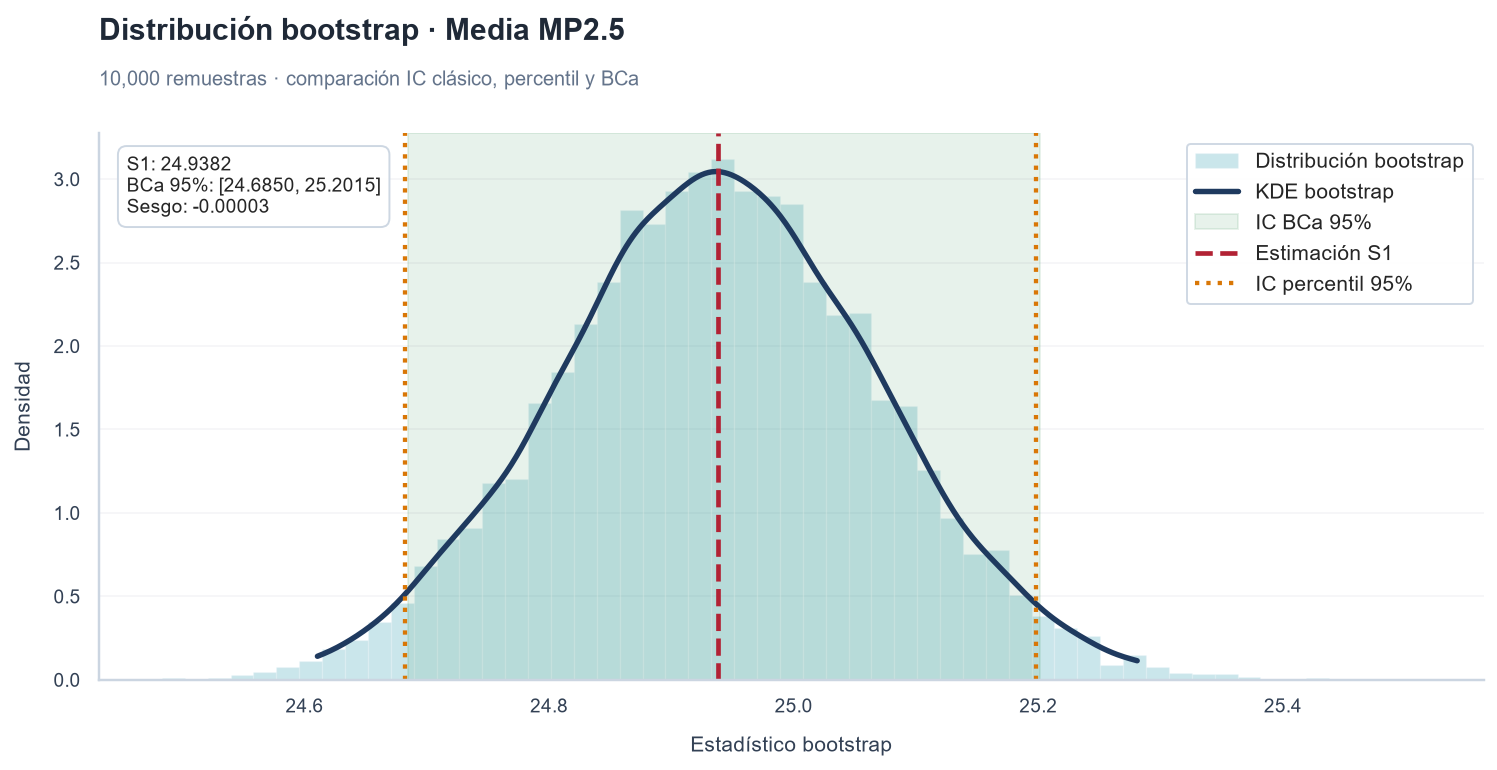

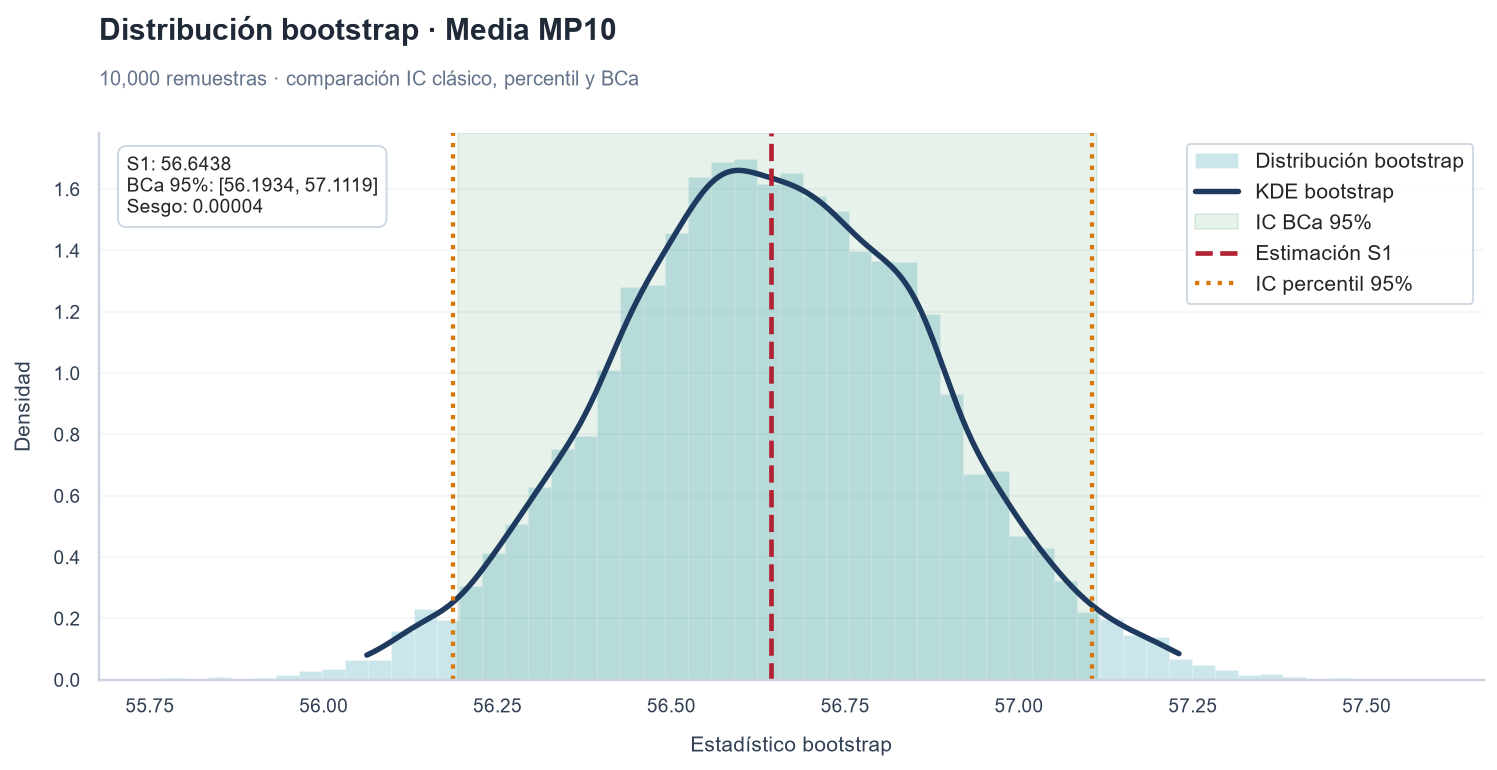

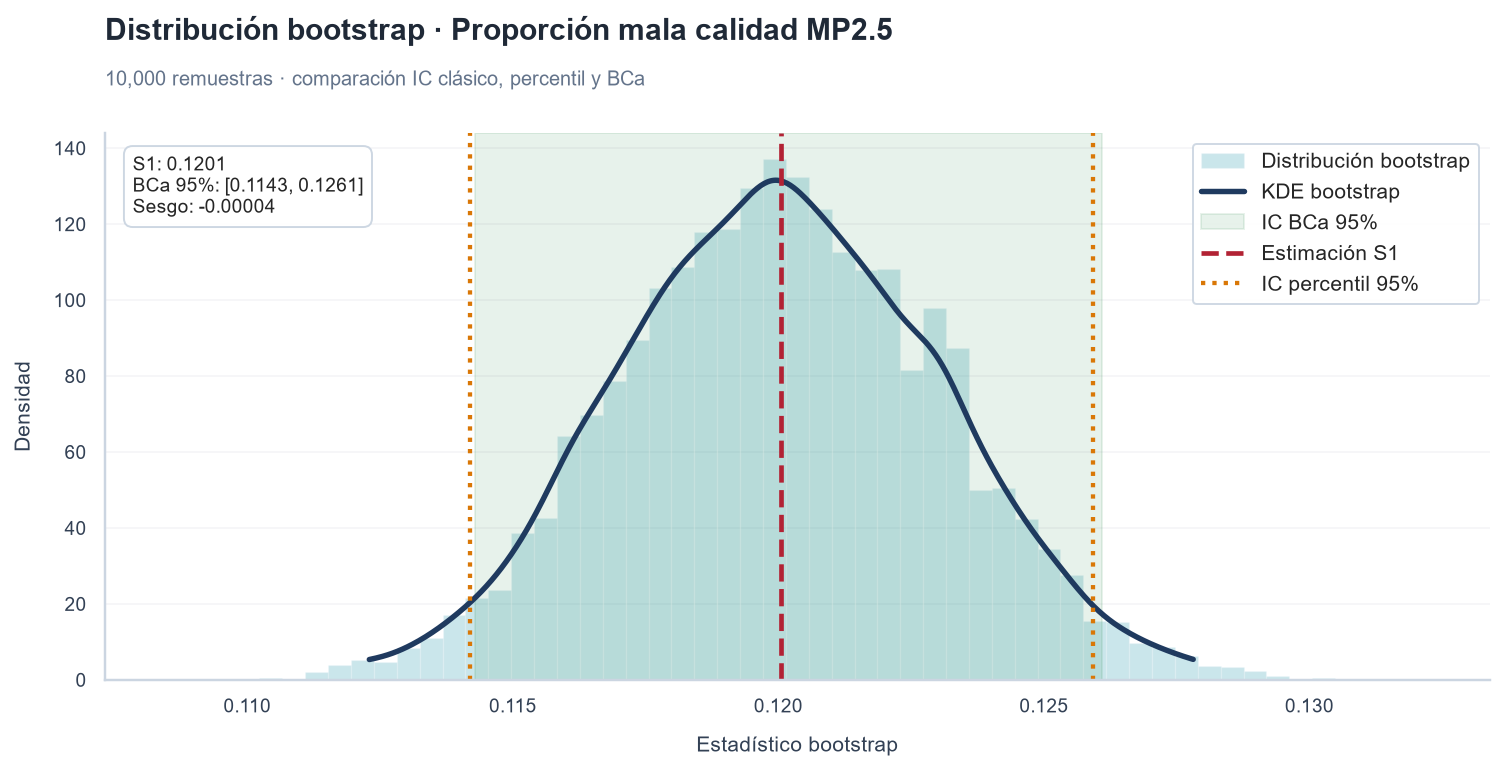

,parametro,variacion_ancho_bca_vs_clasico_%,estado
0,Media MP2.5,1.434458,consistente
1,Media MP10,2.503081,consistente
2,Proporción mala calidad MP2.5,-0.181074,consistente


4.1 ✅ Visualizaciones y análisis de robustez: Logrado.


In [21]:
# =============================================================================
# 4.1 VISUALIZACIONES · BOOTSTRAP
# -----------------------------------------------------------------------------
# Histogramas en densidad + KDE + bandas de IC. Cada figura se exporta en 320 dpi.
# =============================================================================

for parametro, boots in boots_guardados.items():
    fila = resultados_bootstrap[resultados_bootstrap["parametro"] == parametro].iloc[0]
    boots = pd.Series(boots).dropna().astype(float)

    fig, ax = plt.subplots(figsize=(11.5, 6.2))

    ax.hist(
        boots,
        bins=55,
        density=True,
        color=COLORS["cyan"],
        alpha=0.22,
        edgecolor="white",
        linewidth=0.7,
        label="Distribución bootstrap"
    )
    kde_line(ax, boots, COLORS["navy"], label="KDE bootstrap", lw=2.8)

    ax.axvspan(
        fila["ic_bca_li"],
        fila["ic_bca_ls"],
        color=COLORS["green"],
        alpha=0.10,
        label="IC BCa 95%"
    )
    ax.axvline(fila["estimacion_s1"], color=COLORS["red"], linestyle="--", linewidth=2.4, label="Estimación S1")
    ax.axvline(fila["ic_percentil_li"], color=COLORS["amber"], linestyle=":", linewidth=2.2, label="IC percentil 95%")
    ax.axvline(fila["ic_percentil_ls"], color=COLORS["amber"], linestyle=":", linewidth=2.2)

    estilo_premium_ax(
        ax,
        titulo=f"Distribución bootstrap · {parametro}",
        subtitulo=f"{N_BOOT:,} remuestras · comparación IC clásico, percentil y BCa",
        xlabel="Estadístico bootstrap",
        ylabel="Densidad"
    )
    ax.legend(loc="upper right")

    texto = (
        f"S1: {fila['estimacion_s1']:.4f}\n"
        f"BCa 95%: [{fila['ic_bca_li']:.4f}, {fila['ic_bca_ls']:.4f}]\n"
        f"Sesgo: {fila['sesgo_bootstrap']:.5f}"
    )
    ax.text(
        0.02, 0.96, texto,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.45", facecolor="white", edgecolor="#CBD5E1", alpha=0.95)
    )

    guardar_figura(f"bootstrap_premium_{parametro.lower().replace(' ','_').replace('.','').replace('/','_')}.png")
    plt.show()

interpretacion_bootstrap = []
for _, r0 in resultados_bootstrap.iterrows():
    ancho_c = r0["ic_clasico_ls"] - r0["ic_clasico_li"]
    ancho_b = r0["ic_bca_ls"] - r0["ic_bca_li"]
    dif = 100 * (ancho_b - ancho_c) / ancho_c if ancho_c != 0 else np.nan
    estado = "consistente" if abs(dif) < 15 else "requiere cautela"
    interpretacion_bootstrap.append({
        "parametro": r0["parametro"],
        "variacion_ancho_bca_vs_clasico_%": dif,
        "estado": estado
    })

interpretacion_bootstrap = pd.DataFrame(interpretacion_bootstrap)
display(interpretacion_bootstrap)

tarjeta_interpretacion(
    "4.1 📌 Interpretación gráfica · Bootstrap",
    [
        "Las curvas KDE permiten verificar visualmente la forma de la distribución empírica del estimador.",
        "La banda verde representa el IC BCa 95%, más exigente que el percentil porque corrige sesgo y aceleración.",
        "Cuando la línea roja de S1 queda centrada dentro de la masa bootstrap, la estimación original se considera estable.",
        "Diferencias relevantes entre IC clásico y BCa deben explicarse por asimetría, sesgo o no normalidad del estadístico."
    ],
    COLORS["cyan"],
    "El bootstrap valida la incertidumbre de S1 con evidencia empírica y no solo con supuestos paramétricos."
)
# --- CONFIRMACIÓN FINAL DE VISUALIZACIÓN ---
try:
    # Verificamos si el DataFrame de interpretación se generó correctamente
    if not interpretacion_bootstrap.empty:
        print("4.1 ✅ Visualizaciones y análisis de robustez: Logrado.")
    else:
        print("4.1 ⚠️ Visualizaciones generadas, pero el DataFrame de interpretación está vacío.")
except Exception as e:
    print(f"4.1 ❌ Error durante el proceso de visualización: {e}")

<div style="background:#ffffff;border:1px solid #dbe5ef;border-left:7px solid #2563eb;border-radius:14px;padding:22px 26px;margin:18px 0;font-family:Arial,Helvetica,sans-serif;color:#0f172a;line-height:1.65;max-width:100%;box-sizing:border-box;overflow-wrap:break-word;word-break:normal;">

<h2 style="margin:0 0 16px 0;padding:16px 20px;background:#f8fafc;border:1px solid #dbe5ef;border-left:6px solid #2563eb;border-radius:10px;color:#0f172a;font-size:26px;font-weight:900;line-height:1.25;box-sizing:border-box;max-width:100%;">5. Validación de hipótesis mediante permutación</h2>

<p style="margin:0 0 14px 0;font-size:15px;">Esta sección valida una de las <b>pruebas de hipótesis desarrolladas en la Sumativa 1</b> utilizando un enfoque de <b>permutación no paramétrica</b>. Para ello se generan al menos <b>10.000 permutaciones aleatorias</b>, obteniendo la distribución nula empírica del estadístico de prueba y calculando el <b>p-value de permutación</b>, el cual se compara con el <b>p-value paramétrico</b> para evaluar la consistencia y robustez de la inferencia estadística.</p>

<div style="margin-top:18px;padding:14px 18px;background:#f8fafc;border:1px solid #dbe5ef;border-left:5px solid #2563eb;border-radius:10px;box-sizing:border-box;max-width:100%;">

<div style="font-weight:900;color:#2563eb;font-size:16px;margin-bottom:8px;">🎯 Resultado esperado</div>

<div style="font-size:15px;line-height:1.65;">Hipótesis de la Sumativa 1 validada mediante <b>10.000 permutaciones</b>, con comparación entre el <b>p-value de permutación</b> y el <b>p-value paramétrico</b>, demostrando la consistencia de la decisión estadística y la robustez de las conclusiones inferenciales frente a supuestos distribucionales.</div>

</div>

</div>

In [22]:
# =============================================================================
# 5. TEST DE PERMUTACIÓN
# -----------------------------------------------------------------------------
# Valida por remuestreo la prueba paramétrica base recuperada desde S1:
# comparación de MP2.5 entre temporada crítica/invierno y resto del año.
# =============================================================================

VAR_GRUPO = pruebas_s1.loc[0, "grupo"]
G1 = pruebas_s1.loc[0, "grupo_1"]
G2 = pruebas_s1.loc[0, "grupo_2"]

base_perm = df[[COL_MP25, VAR_GRUPO]].dropna().copy()
base_perm[VAR_GRUPO] = base_perm[VAR_GRUPO].astype(str)

x1 = base_perm.loc[base_perm[VAR_GRUPO] == str(G1), COL_MP25].astype(float).values
x2 = base_perm.loc[base_perm[VAR_GRUPO] == str(G2), COL_MP25].astype(float).values

if len(x1) < 2 or len(x2) < 2:
    raise ValueError(
        f"No hay datos suficientes para permutación: {VAR_GRUPO} = {G1} ({len(x1)}) vs {G2} ({len(x2)})."
    )

obs = x1.mean() - x2.mean()
combined = np.concatenate([x1, x2])
n1 = len(x1)
perm_stats = np.empty(N_PERM)

for i in range(N_PERM):
    perm = rng.permutation(combined)
    perm_stats[i] = perm[:n1].mean() - perm[n1:].mean()

p_perm = np.mean(np.abs(perm_stats) >= abs(obs))
t_stat, p_param = stats.ttest_ind(x1, x2, equal_var=False)

resultado_perm = pd.DataFrame([{
    "prueba_validada_s1": pruebas_s1.loc[0, "prueba"],
    "variable": COL_MP25,
    "grupo": VAR_GRUPO,
    "grupo_1": G1,
    "grupo_2": G2,
    "n_grupo_1": len(x1),
    "n_grupo_2": len(x2),
    "diferencia_observada": obs,
    "p_parametrico_welch": p_param,
    "p_permutacion": p_perm,
    "n_permutaciones": N_PERM,
    "conclusion": "concordante" if (p_param < ALPHA) == (p_perm < ALPHA) else "discrepante"
}])

resultado_perm.to_csv(RESULTS_DIR / "s2_test_permutacion.csv", index=False, encoding="utf-8-sig")

tarjeta(
    "✅ Sección 5 · Permutación ejecutada",
    (
        f"Prueba validada: <b>{pruebas_s1.loc[0, 'prueba']}</b><br>"
        f"Permutaciones: <b>{N_PERM:,}</b><br>"
        f"p paramétrico Welch = <b>{p_param:.3e}</b> · p permutación = <b>{p_perm:.3e}</b>."
    ),
    COLORS["amber"]
)

display(resultado_perm)

tarjeta_interpretacion(
    "Sección 5. 📌 Interpretación · Test de permutación",
    [
        f"La diferencia observada entre grupos fue <b>{obs:.4f}</b> µg/m³.",
        f"El contraste paramétrico Welch entrega p = <b>{p_param:.3e}</b>, mientras que la permutación entrega p = <b>{p_perm:.3e}</b>.",
        f"La conclusión entre ambos enfoques es <b>{resultado_perm.loc[0, 'conclusion']}</b> al nivel α = {ALPHA}.",
        "La permutación aporta una validación no paramétrica porque construye la distribución nula reordenando las etiquetas de grupo, con menor dependencia de normalidad."
    ],
    COLORS["amber"],
    "Cuando ambos p-values apuntan a la misma decisión, la evidencia inferencial de S1 queda fortalecida."
)
# --- CONFIRMACIÓN DE EJECUCIÓN ---
if 'resultado_perm' in locals() and not resultado_perm.empty:
    print("5. ✅ Test de permutación: Logrado.")
else:
    print("5. ❌ Error: El test de permutación no generó resultados.")

,prueba_validada_s1,variable,grupo,grupo_1,grupo_2,n_grupo_1,n_grupo_2,diferencia_observada,p_parametrico_welch,p_permutacion,n_permutaciones,conclusion
0,MP2.5: Invierno vs Resto del año,mp2_5_mean,temporada_critica,Invierno,Resto del año,3915,7688,22.316457,0.0,0.0,10000,concordante


5. ✅ Test de permutación: Logrado.


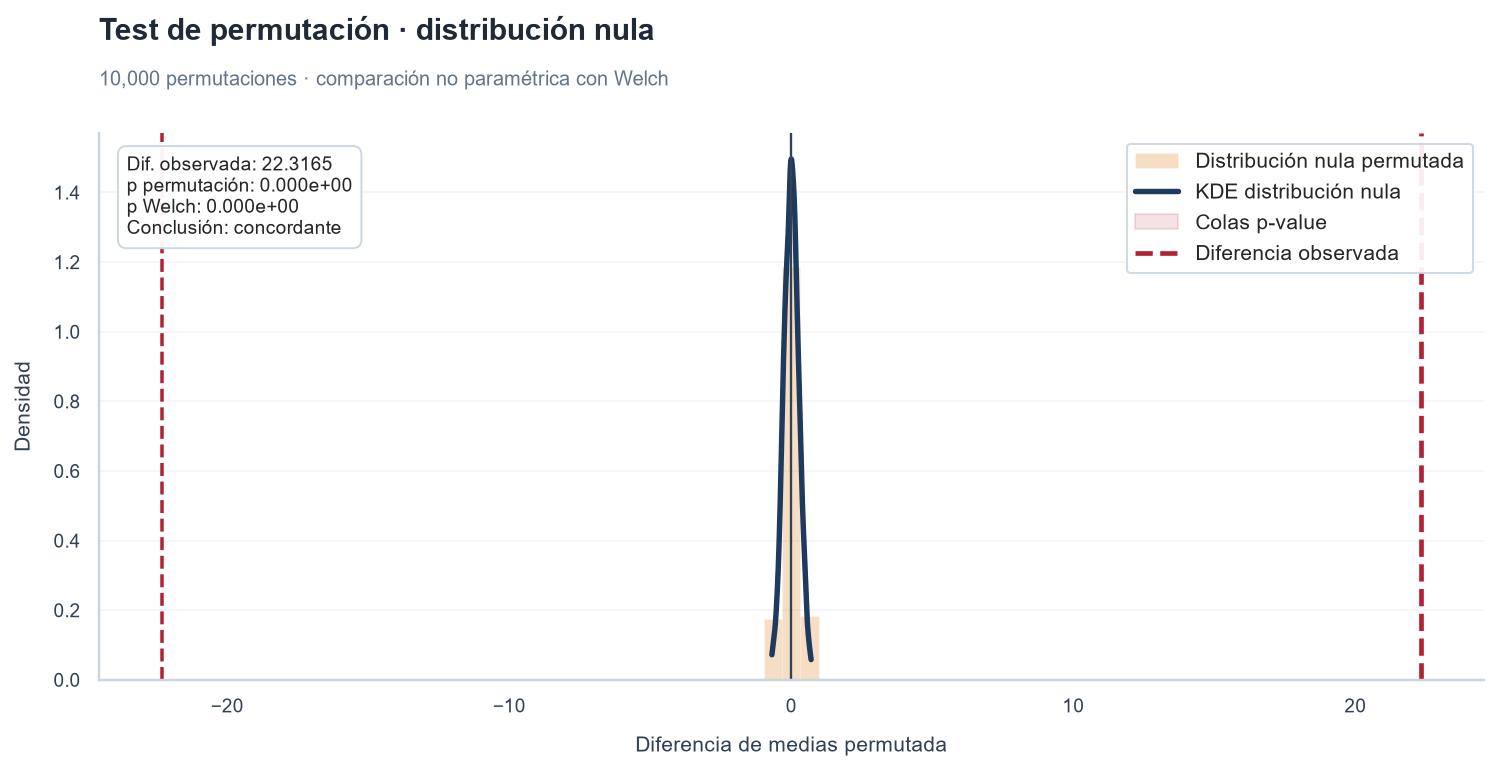

In [23]:
# =============================================================================
# 5.1 VISUALIZACIÓN PREMIUM · DISTRIBUCIÓN NULA POR PERMUTACIÓN
# =============================================================================

fig, ax = plt.subplots(figsize=(11.5, 6.2))

perm_series = pd.Series(perm_stats).dropna().astype(float)
lim = max(abs(np.nanpercentile(perm_series, 0.5)), abs(np.nanpercentile(perm_series, 99.5)), abs(obs))
bins = np.linspace(-lim, lim, 70)

ax.hist(
    perm_series,
    bins=bins,
    density=True,
    color=COLORS["amber"],
    alpha=0.24,
    edgecolor="white",
    linewidth=0.7,
    label="Distribución nula permutada"
)
kde_line(ax, perm_series, COLORS["navy"], label="KDE distribución nula", lw=2.8)

# Sombrear colas tan extremas como el estadístico observado
xs = np.linspace(-lim, lim, 800)
kde = stats.gaussian_kde(perm_series)
ys = kde(xs)
ax.fill_between(xs, 0, ys, where=(xs <= -abs(obs)), color=COLORS["red"], alpha=0.13, label="Colas p-value")
ax.fill_between(xs, 0, ys, where=(xs >= abs(obs)), color=COLORS["red"], alpha=0.13)

ax.axvline(obs, color=COLORS["red"], linestyle="--", linewidth=2.4, label="Diferencia observada")
ax.axvline(-obs, color=COLORS["red"], linestyle="--", linewidth=1.8)
ax.axvline(0, color=COLORS["slate"], linewidth=1.2)

estilo_premium_ax(
    ax,
    titulo="Test de permutación · distribución nula",
    subtitulo=f"{N_PERM:,} permutaciones · comparación no paramétrica con Welch",
    xlabel="Diferencia de medias permutada",
    ylabel="Densidad"
)
ax.legend(loc="upper right")

texto = (
    f"Dif. observada: {obs:.4f}\n"
    f"p permutación: {p_perm:.3e}\n"
    f"p Welch: {p_param:.3e}\n"
    f"Conclusión: {resultado_perm.loc[0, 'conclusion']}"
)
ax.text(
    0.02, 0.96, texto,
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.45", facecolor="white", edgecolor="#CBD5E1", alpha=0.95)
)

guardar_figura("permutacion_premium_distribucion_nula.png")
plt.show()

lectura = (
    "El resultado de permutación confirma la prueba paramétrica."
    if resultado_perm.loc[0, "conclusion"] == "concordante"
    else "El resultado difiere del paramétrico; reportar ambos y priorizar permutación por menor dependencia de supuestos."
)

tarjeta_interpretacion(
    "Seccion 5.1: 📌 Interpretación gráfica · Permutación",
    [
        "La distribución nula muestra qué diferencias de medias serían esperables si la etiqueta de grupo no tuviera efecto.",
        "Las áreas sombreadas representan diferencias tan extremas como la observada; su masa corresponde al p-value de permutación.",
        f"Como p permutación = <b>{p_perm:.3e}</b>, la decisión estadística es <b>{'rechazar H0' if p_perm < ALPHA else 'no rechazar H0'}</b> con α = {ALPHA}.",
        "La comparación con Welch permite detectar si la conclusión depende de supuestos paramétricos."
    ],
    COLORS["amber"],
    lectura
)


<div style="background:#ffffff;border:1px solid #dbe5ef;border-left:7px solid #2563eb;border-radius:14px;padding:22px 26px;margin:18px 0;font-family:Arial,Helvetica,sans-serif;color:#0f172a;line-height:1.65;max-width:100%;box-sizing:border-box;overflow-wrap:break-word;word-break:normal;">

<h2 style="margin:0 0 16px 0;padding:16px 20px;background:#f8fafc;border:1px solid #dbe5ef;border-left:6px solid #2563eb;border-radius:10px;color:#0f172a;font-size:26px;font-weight:900;line-height:1.25;box-sizing:border-box;max-width:100%;">6. Estabilidad de correlaciones</h2>

<p style="margin:0 0 14px 0;font-size:15px;">Esta sección evalúa la <b>estabilidad de las correlaciones más relevantes obtenidas en la Sumativa 1</b> mediante <b>bootstrap no paramétrico</b>, estimando para cada coeficiente un <b>intervalo de confianza del 95%</b>. Se analizan entre <b>3 y 5 correlaciones representativas</b>, identificando aquellas que presentan un comportamiento <b>robusto</b> o <b>inestable</b>, considerando la variabilidad de las estimaciones y verificando si el intervalo de confianza incluye el valor cero.</p>

<div style="margin-top:18px;padding:14px 18px;background:#f8fafc;border:1px solid #dbe5ef;border-left:5px solid #2563eb;border-radius:10px;box-sizing:border-box;max-width:100%;">

<div style="font-weight:900;color:#2563eb;font-size:16px;margin-bottom:8px;">🎯 Resultado esperado</div>

<div style="font-size:15px;line-height:1.65;">Correlaciones de la Sumativa 1 validadas mediante <b>intervalos de confianza bootstrap al 95%</b>, clasificando cada relación como <b>robusta</b> o <b>inestable</b> según su variabilidad y la inclusión del valor cero en el intervalo de confianza, proporcionando evidencia sobre la confiabilidad de las asociaciones identificadas.</div>

</div>

</div>

In [24]:
# =============================================================================
# 6. CORRELACIONES BOOTSTRAP
# =============================================================================
candidatos=[(COL_MP25,COL_MP10),(COL_MP25,"humedad_mean"),(COL_MP25,"temperatura_mean"),(COL_MP25,"viento_mean"),(COL_MP25,"prop_inversion"),(COL_MP10,"humedad_mean")]
pares=[(a,b) for a,b in candidatos if a in df.columns and b in df.columns][:5]
if len(pares)<3: raise ValueError("Se requieren al menos 3 pares disponibles.")

def bootstrap_correlacion(data,a,b,n_boot=N_BOOT,seed=SEED):
    tmp=data[[a,b]].dropna().astype(float); vals=tmp.values; n=len(tmp); rr=np.random.default_rng(seed); boots=np.empty(n_boot)
    for i in range(n_boot):
        m=vals[rr.integers(0,n,size=n)]; boots[i]=np.corrcoef(m[:,0],m[:,1])[0,1]
    return tmp.corr().iloc[0,1], boots, n

resultados_corr=[]; corr_boots={}
for a,b in pares:
    r_obs,boots,n=bootstrap_correlacion(df,a,b); li,ls=np.percentile(boots,[2.5,97.5])
    robusta=(li>0 and ls>0) or (li<0 and ls<0); alta_var=boots.std(ddof=1)>0.05
    resultados_corr.append({"variable_x":a,"variable_y":b,"correlacion_s1":r_obs,"ic_bootstrap_li":li,"ic_bootstrap_ls":ls,"incluye_cero":bool(li<=0<=ls),"desv_bootstrap":boots.std(ddof=1),"estado":"robusta" if robusta and not alta_var else "inestable / cautela","n":n,"n_boot":N_BOOT})
    corr_boots[f"{a} vs {b}"]=boots
resultados_corr=pd.DataFrame(resultados_corr)
resultados_corr.to_csv(RESULTS_DIR/"s2_correlaciones_bootstrap.csv", index=False)
tarjeta("✅ Sección 6 · Correlaciones evaluadas", f"Se evaluaron {len(resultados_corr)} correlaciones con {N_BOOT:,} remuestras.", COLORS["navy"])
display(resultados_corr)

robustas = int((resultados_corr["estado"] == "robusta").sum())
inestables = int(len(resultados_corr) - robustas)
tarjeta_interpretacion(
    "Sección 6: 📌 Interpretación · Estabilidad de correlaciones",
    [
        f"Se evaluaron <b>{len(resultados_corr)}</b> correlaciones relevantes de S1 mediante IC bootstrap al 95%.",
        f"Correlaciones clasificadas como robustas: <b>{robustas}</b>; correlaciones con cautela o inestables: <b>{inestables}</b>.",
        "Una correlación se considera robusta cuando su intervalo no cruza cero y su variabilidad bootstrap es acotada.",
        "Las correlaciones cuyo IC incluye cero no deben usarse como evidencia fuerte en S3, aunque pueden mantenerse como variables exploratorias."
    ],
    COLORS["navy"],
    "Esta sección distingue relaciones estables de asociaciones sensibles a la muestra."
)

,variable_x,variable_y,correlacion_s1,ic_bootstrap_li,ic_bootstrap_ls,incluye_cero,desv_bootstrap,estado,n,n_boot
0,mp2_5_mean,mp10_mean,0.901117,0.896135,0.905799,False,0.002456,robusta,11590,10000
1,mp2_5_mean,humedad_mean,0.326114,0.306550,0.345305,False,0.009852,robusta,11603,10000
2,mp2_5_mean,temperatura_mean,-0.620646,-0.630656,-0.610421,False,0.005133,robusta,11603,10000
3,mp2_5_mean,viento_mean,0.184570,0.159103,0.210636,False,0.013039,robusta,11603,10000
4,mp2_5_mean,prop_inversion,0.519387,0.501262,0.537271,False,0.009145,robusta,11603,10000


,variable_x,variable_y,correlacion_s1,ic_bootstrap_li,ic_bootstrap_ls,incluye_cero,desv_bootstrap,estado,n,n_boot
0,mp2_5_mean,mp10_mean,0.901117,0.896135,0.905799,False,0.002456,robusta,11590,10000
1,mp2_5_mean,humedad_mean,0.326114,0.306550,0.345305,False,0.009852,robusta,11603,10000
2,mp2_5_mean,temperatura_mean,-0.620646,-0.630656,-0.610421,False,0.005133,robusta,11603,10000
3,mp2_5_mean,viento_mean,0.184570,0.159103,0.210636,False,0.013039,robusta,11603,10000
4,mp2_5_mean,prop_inversion,0.519387,0.501262,0.537271,False,0.009145,robusta,11603,10000


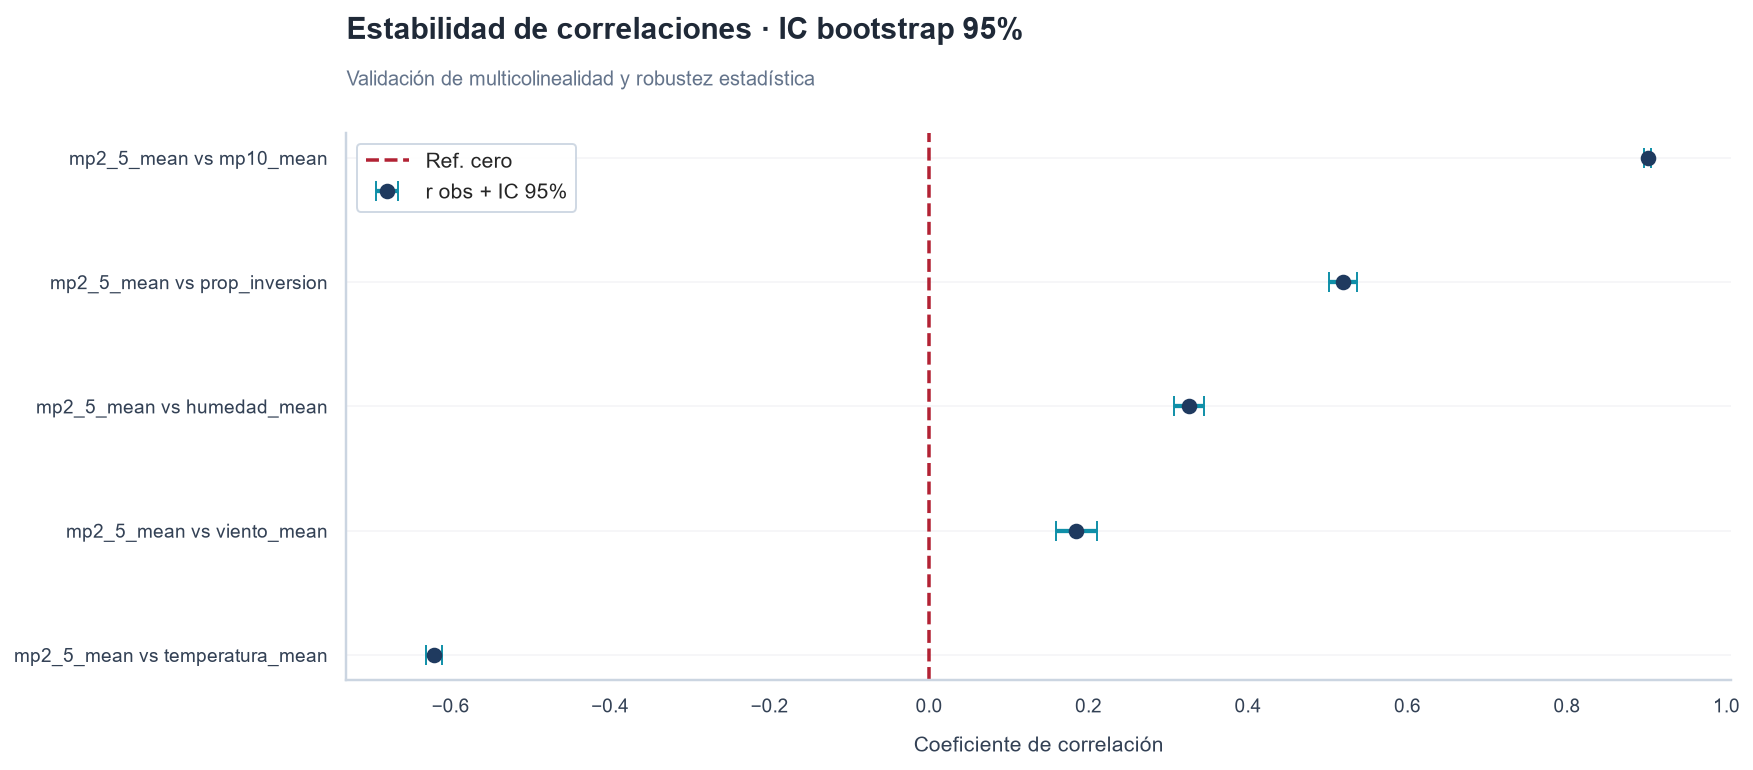

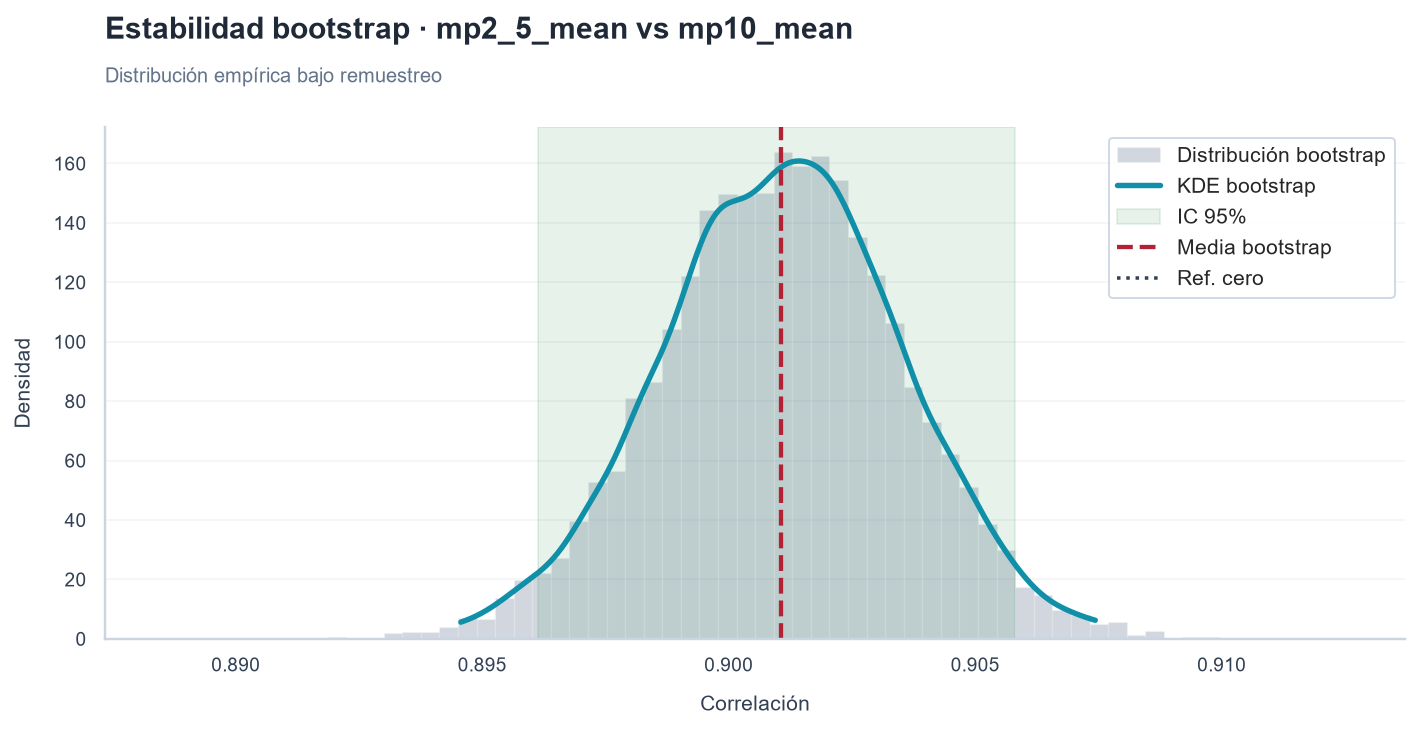

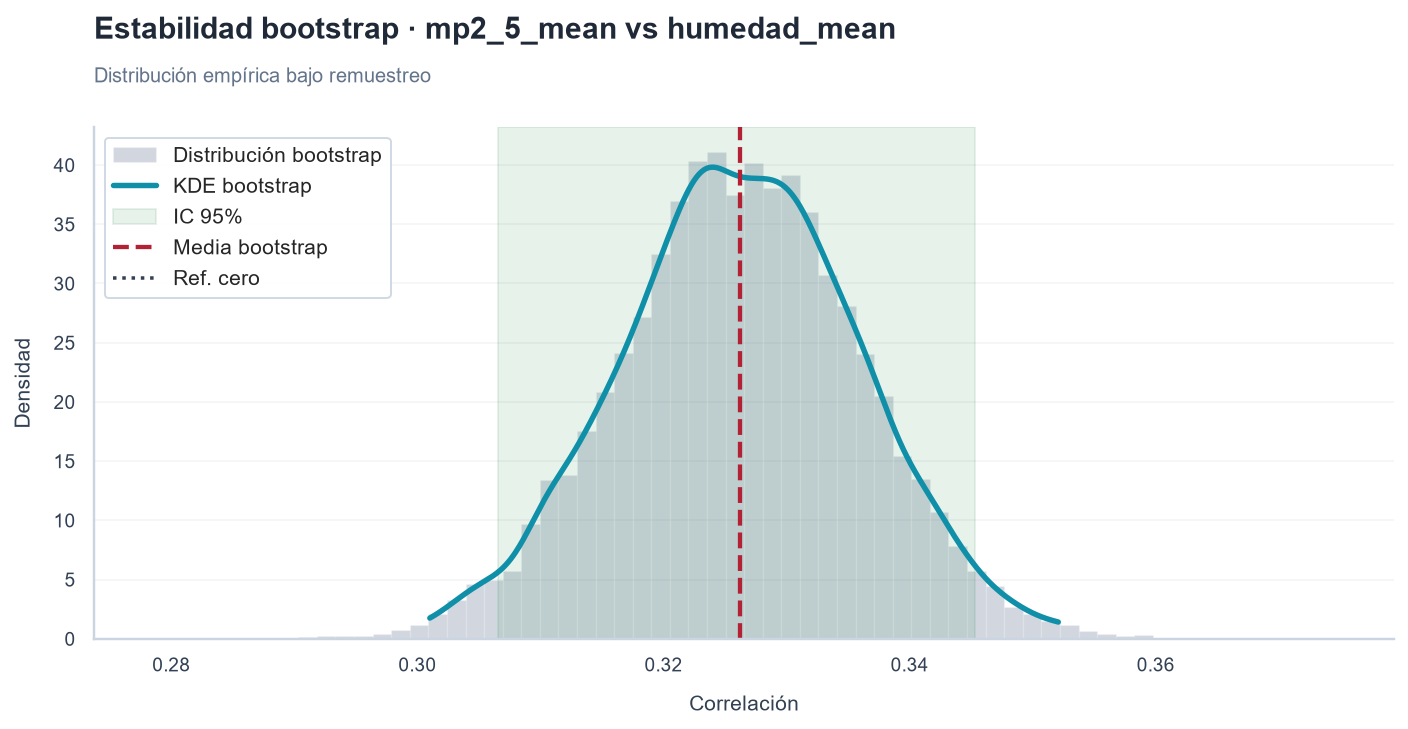

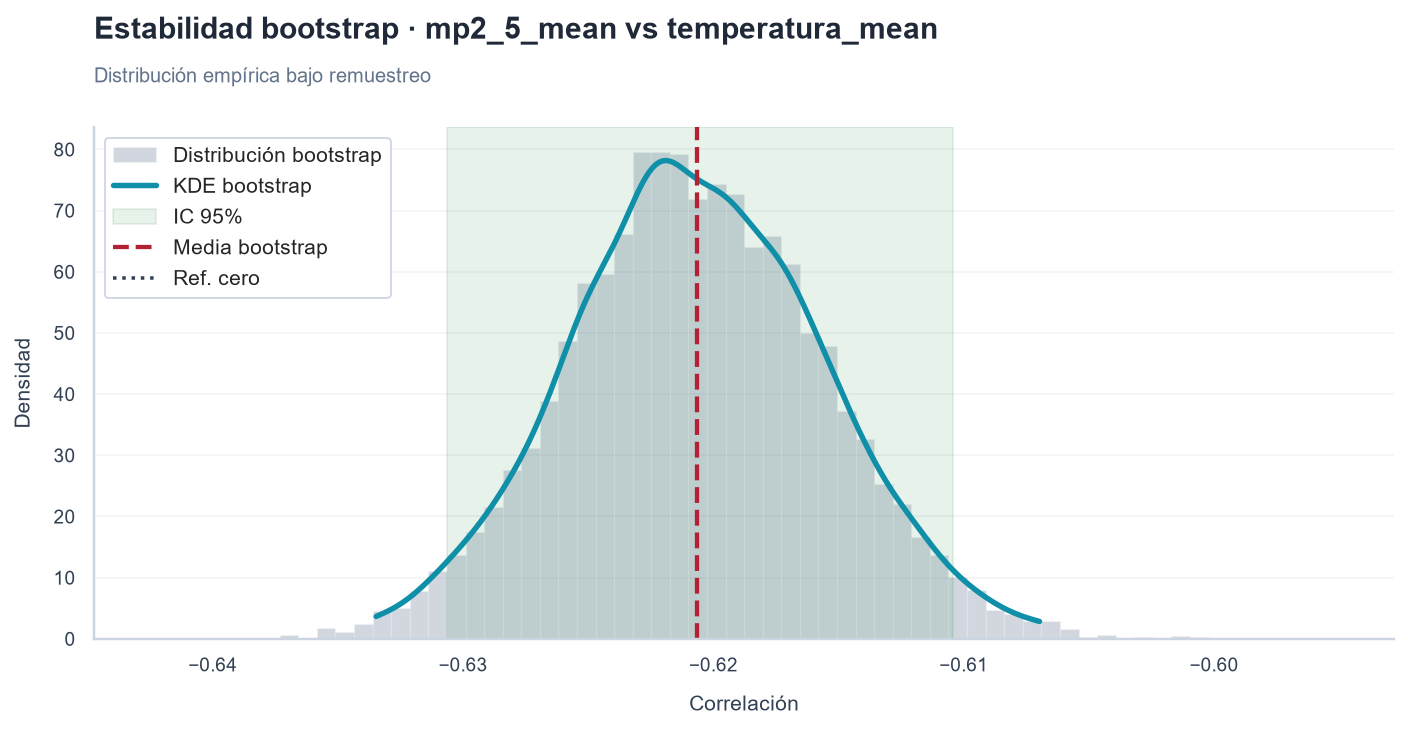

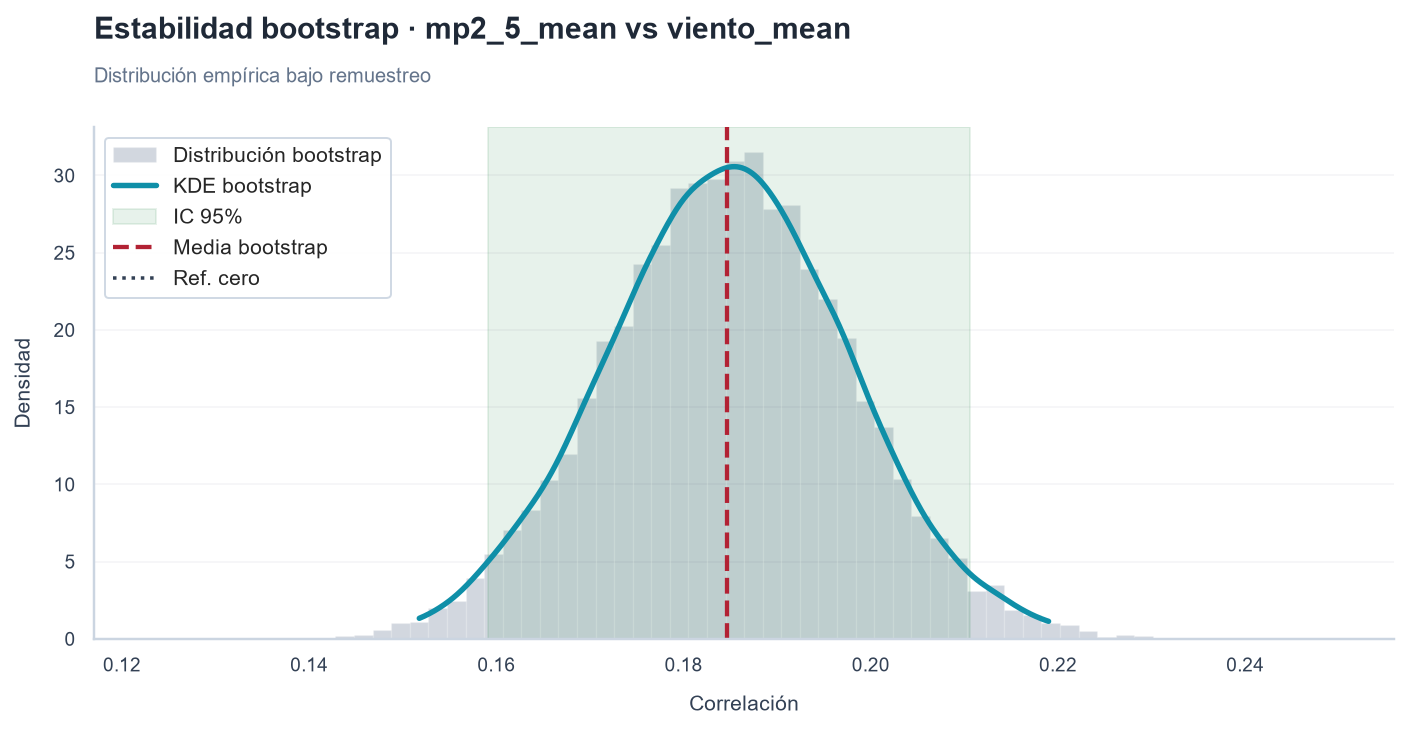

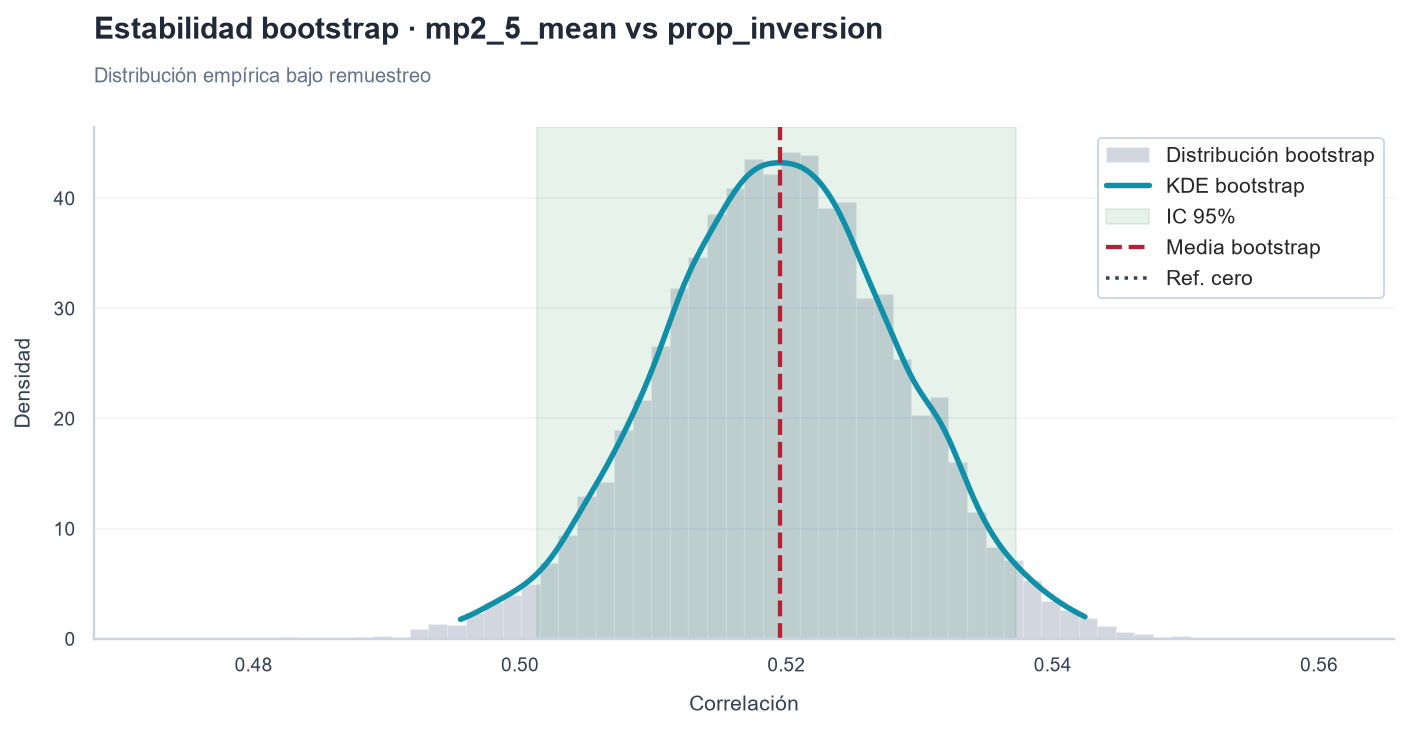

6.1 ✅ Análisis de correlaciones: Logrado.


In [25]:
# =============================================================================
# 6.1 CORRELACIONES BOOTSTRAP (VERSION OPTIMIZADA)
# =============================================================================

# Definición de candidatos
candidatos = [(COL_MP25, COL_MP10), (COL_MP25, "humedad_mean"), 
              (COL_MP25, "temperatura_mean"), (COL_MP25, "viento_mean"), 
              (COL_MP25, "prop_inversion"), (COL_MP10, "humedad_mean")]
pares = [(a, b) for a, b in candidatos if a in df.columns and b in df.columns][:5]

if len(pares) < 3: 
    raise ValueError("Se requieren al menos 3 pares disponibles para el análisis.")

def bootstrap_correlacion(data, a, b, n_boot=N_BOOT, seed=SEED):
    tmp = data[[a, b]].dropna().astype(float)
    vals = tmp.values
    n = len(tmp)
    rr = np.random.default_rng(seed)
    boots = np.empty(n_boot)
    
    # Vectorización simple: calculamos correlaciones por remuestreo
    for i in range(n_boot):
        m = vals[rr.integers(0, n, size=n)]
        boots[i] = np.corrcoef(m[:, 0], m[:, 1])[0, 1]
    return tmp.corr().iloc[0, 1], boots, n

# Ejecución
resultados_corr = []
corr_boots = {}
for a, b in pares:
    r_obs, boots, n = bootstrap_correlacion(df, a, b)
    li, ls = np.percentile(boots, [2.5, 97.5])
    robusta = (li > 0 and ls > 0) or (li < 0 and ls < 0)
    alta_var = boots.std(ddof=1) > 0.05
    resultados_corr.append({
        "variable_x": a, "variable_y": b, "correlacion_s1": r_obs,
        "ic_bootstrap_li": li, "ic_bootstrap_ls": ls,
        "incluye_cero": bool(li <= 0 <= ls),
        "desv_bootstrap": boots.std(ddof=1),
        "estado": "robusta" if robusta and not alta_var else "inestable / cautela",
        "n": n, "n_boot": N_BOOT
    })
    corr_boots[f"{a} vs {b}"] = boots

resultados_corr = pd.DataFrame(resultados_corr)
resultados_corr.to_csv(RESULTS_DIR / "s2_correlaciones_bootstrap.csv", index=False)
display(resultados_corr)

# =============================================================================
# 6.1 VISUALIZACIONES PREMIUM · CORRELACIONES BOOTSTRAP
# =============================================================================

# Gráfico 1: Ranking con IC dinámico
corr_plot = resultados_corr.sort_values("correlacion_s1")
corr_plot["par"] = corr_plot["variable_x"] + " vs " + corr_plot["variable_y"]

fig, ax = plt.subplots(figsize=(11.5, 6.2))
y = np.arange(len(corr_plot))
x = corr_plot["correlacion_s1"].astype(float).values
xerr = np.vstack([x - corr_plot["ic_bootstrap_li"].astype(float).values,
                  corr_plot["ic_bootstrap_ls"].astype(float).values - x])

ax.errorbar(x, y, xerr=xerr, fmt="o", color=COLORS["navy"], ecolor=COLORS["cyan"], 
            elinewidth=2.2, capsize=5, markersize=7, label="r obs + IC 95%")
ax.axvline(0, color=COLORS["red"], linestyle="--", linewidth=1.8, label="Ref. cero")

# Límite dinámico con aire extra
ax.set_xlim(min(corr_plot["ic_bootstrap_li"].min() - 0.1, -0.2), 
            min(1.05, corr_plot["ic_bootstrap_ls"].max() + 0.1))

ax.set_yticks(y)
ax.set_yticklabels(corr_plot["par"])
ax.legend(loc="upper left")
estilo_premium_ax(ax, titulo="Estabilidad de correlaciones · IC bootstrap 95%",
                  subtitulo="Validación de multicolinealidad y robustez estadística",
                  xlabel="Coeficiente de correlación", ylabel="")
guardar_figura("correlaciones_premium_ic_bootstrap.png")
plt.show()

# Gráfico 2: Densidades bootstrap centradas
for nombre, boots in corr_boots.items():
    boots = pd.Series(boots).dropna().astype(float)
    li, ls = np.percentile(boots, [2.5, 97.5])
    media = boots.mean()

    fig, ax = plt.subplots(figsize=(10.8, 5.8))
    ax.hist(boots, bins=50, density=True, color=COLORS["navy"], alpha=0.20, 
            edgecolor="white", linewidth=0.7, label="Distribución bootstrap")
    kde_line(ax, boots, COLORS["cyan"], label="KDE bootstrap", lw=2.8)
    ax.axvspan(li, ls, color=COLORS["green"], alpha=0.10, label="IC 95%")
    ax.axvline(media, color=COLORS["red"], linestyle="--", linewidth=2.2, label="Media bootstrap")
    ax.axvline(0, color=COLORS["slate"], linestyle=":", linewidth=1.8, label="Ref. cero")

    # Ajuste dinámico de escala
    padding = (boots.max() - boots.min()) * 0.2
    ax.set_xlim(max(-1, boots.min() - padding), min(1, boots.max() + padding))
    
    estilo_premium_ax(ax, titulo=f"Estabilidad bootstrap · {nombre}", 
                      subtitulo="Distribución empírica bajo remuestreo", 
                      xlabel="Correlación", ylabel="Densidad")
    ax.legend(loc="upper left" if media < 0.5 else "upper right")
    guardar_figura(f"correlacion_premium_{nombre.replace(' ','_').replace('/','_')}.png")
    plt.show()

print("6.1 ✅ Análisis de correlaciones: Logrado.")

<div style="
background:#f8fafc;
border-left:7px solid #2563eb;
border-radius:14px;
padding:22px 26px;
margin:18px 0;
box-shadow:0 6px 18px rgba(15,23,42,.12);
font-family:Arial,Helvetica,sans-serif;
color:#0f172a;
line-height:1.65;
max-width:100%;
box-sizing:border-box;
">

  <h3 style="margin:0 0 14px 0;color:#1d4ed8;font-size:18px;font-weight:900;">
    6.1 📊 Lectura crítica complementaria de correlaciones
  </h3>

  <p style="margin:0 0 14px 0;">
    La estabilidad de una correlación no debe evaluarse solo por el <b>valor puntual observado</b>,
    sino también por la <b>amplitud del intervalo bootstrap</b> y por si este incluye o no el
    <b>valor cero</b>. Cuando el intervalo no cruza cero, la relación observada muestra
    <b>mayor consistencia bajo remuestreo</b>; en cambio, si el intervalo incluye cero o es
    demasiado amplio, la asociación debe interpretarse <b>con cautela</b> para la
    <b>Sumativa 3</b>.
  </p>

  <p style="margin:0;">
    Este criterio permite conectar los resultados de la <b>Sumativa 1</b> con la
    <b>validación computacional de la Sumativa 2</b>, diferenciando entre relaciones que
    parecen <b>robustas</b> y relaciones que podrían depender más de la
    <b>variabilidad muestral</b> o de condiciones específicas del dataset.
  </p>

</div>

<div style="background:#ffffff;border:1px solid #dbe5ef;border-left:7px solid #2563eb;border-radius:14px;padding:22px 26px;margin:18px 0;font-family:Arial,Helvetica,sans-serif;color:#0f172a;line-height:1.65;max-width:100%;box-sizing:border-box;overflow-wrap:break-word;word-break:normal;">

<h2 style="margin:0 0 16px 0;padding:16px 20px;background:#f8fafc;border:1px solid #dbe5ef;border-left:6px solid #2563eb;border-radius:10px;color:#0f172a;font-size:26px;font-weight:900;line-height:1.25;box-sizing:border-box;max-width:100%;">7. Simulación Monte Carlo basada en parámetros de S1</h2>

<p style="margin:0 0 14px 0;font-size:15px;">Esta sección implementa una <b>simulación Monte Carlo</b> utilizando exclusivamente los <b>parámetros estimados en la Sumativa 1</b> para modelar un escenario relevante del estudio. Se ejecutan al menos <b>10.000 iteraciones</b>, analizando la convergencia de la simulación, la distribución de los resultados y los principales estadísticos descriptivos, con el propósito de evaluar la incertidumbre y fortalecer la interpretación de los resultados inferenciales.</p>

<div style="margin-top:18px;padding:14px 18px;background:#f8fafc;border:1px solid #dbe5ef;border-left:5px solid #2563eb;border-radius:10px;box-sizing:border-box;max-width:100%;">

<div style="font-weight:900;color:#2563eb;font-size:16px;margin-bottom:8px;">🎯 Resultado esperado</div>

<div style="font-size:15px;line-height:1.65;">Escenario simulado mediante <b>Monte Carlo</b> con <b>10.000 o más iteraciones</b>, utilizando únicamente parámetros derivados de la Sumativa 1, evidenciando la <b>convergencia</b> de la simulación, la distribución de los resultados, sus principales <b>estadísticos descriptivos</b> y una interpretación que cuantifique la incertidumbre del fenómeno analizado.</div>

</div>

</div>

In [26]:
# =============================================================================
# 7. MONTE CARLO CON PARÁMETROS DE S1
# =============================================================================
x_mp25=df[COL_MP25].dropna().astype(float); media_s1=x_mp25.mean(); sd_s1=x_mp25.std(ddof=1)
sigma2=np.log(1+(sd_s1**2/media_s1**2)); sigma_ln=np.sqrt(sigma2); mu_ln=np.log(media_s1)-sigma2/2
sim_mp25=rng.lognormal(mean=mu_ln, sigma=sigma_ln, size=N_MC)
UMBRAL_REGULAR_MP25=50; UMBRAL_ALERTA_MP25=80; UMBRAL_PREEMERGENCIA_MP25=110
mc_resultados=pd.DataFrame([{"escenario":"MP2.5 diario simulado con parámetros S1","n_iteraciones":N_MC,"media_s1":media_s1,"sd_s1":sd_s1,"media_simulada":sim_mp25.mean(),"p50_simulado":np.percentile(sim_mp25,50),"p95_simulado":np.percentile(sim_mp25,95),"prob_mp25_mayor_50":np.mean(sim_mp25>UMBRAL_REGULAR_MP25),"prob_mp25_mayor_80":np.mean(sim_mp25>UMBRAL_ALERTA_MP25),"prob_mp25_mayor_110":np.mean(sim_mp25>UMBRAL_PREEMERGENCIA_MP25),"mu_lognormal":mu_ln,"sigma_lognormal":sigma_ln}])
mc_resultados.to_csv(RESULTS_DIR/"s2_montecarlo_resultados.csv", index=False)
tarjeta("✅ Sección 7 · Monte Carlo ejecutado", f"Se simularon {N_MC:,} escenarios de MP2.5 con media y desviación estándar de S1.", COLORS["green"])
display(mc_resultados)

tarjeta_interpretacion(
    "Sección 7: 📌 Interpretación · Simulación Monte Carlo",
    [
        f"Se simularon <b>{N_MC:,}</b> escenarios diarios de MP2.5 usando exclusivamente la media y desviación estándar estimadas en S1.",
        f"La probabilidad simulada de superar 50 µg/m³ es <b>{fmt_pct(mc_resultados.loc[0, 'prob_mp25_mayor_50'])}</b>.",
        f"La probabilidad simulada de superar 80 µg/m³ es <b>{fmt_pct(mc_resultados.loc[0, 'prob_mp25_mayor_80'])}</b> y sobre 110 µg/m³ es <b>{fmt_pct(mc_resultados.loc[0, 'prob_mp25_mayor_110'])}</b>.",
        "El percentil 95 simulado permite interpretar escenarios extremos plausibles bajo los parámetros observados en S1."
    ],
    COLORS["green"],
    "Monte Carlo transforma los parámetros estimados en probabilidades de riesgo ambiental útiles para la toma de decisiones."
)

,escenario,n_iteraciones,media_s1,sd_s1,media_simulada,p50_simulado,p95_simulado,prob_mp25_mayor_50,prob_mp25_mayor_80,prob_mp25_mayor_110,mu_lognormal,sigma_lognormal
0,MP2.5 diario simulado con parámetros S1,10000,24.938202,13.990544,24.568114,21.477467,50.0494,0.0505,0.0065,0.001,3.079585,0.523098


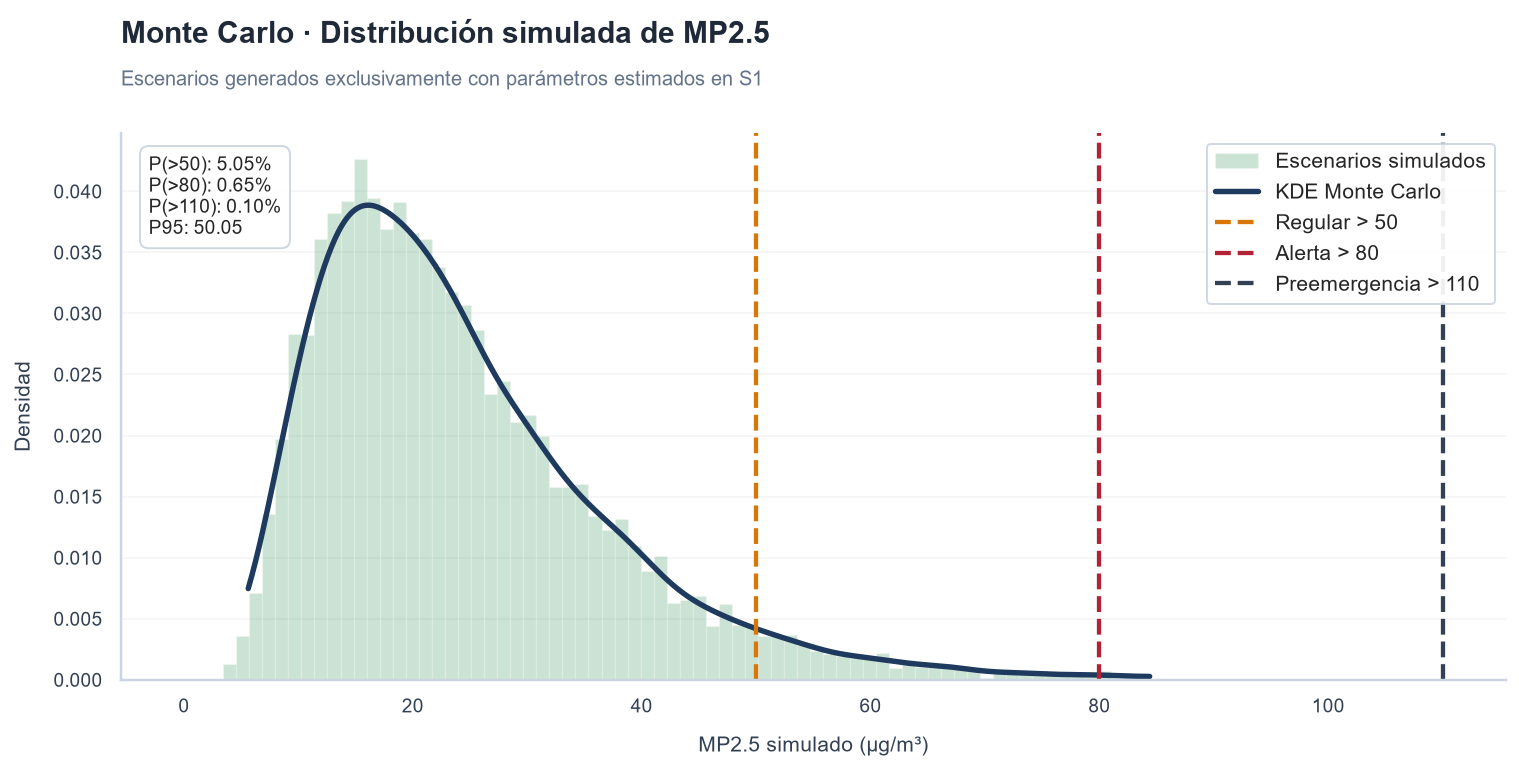

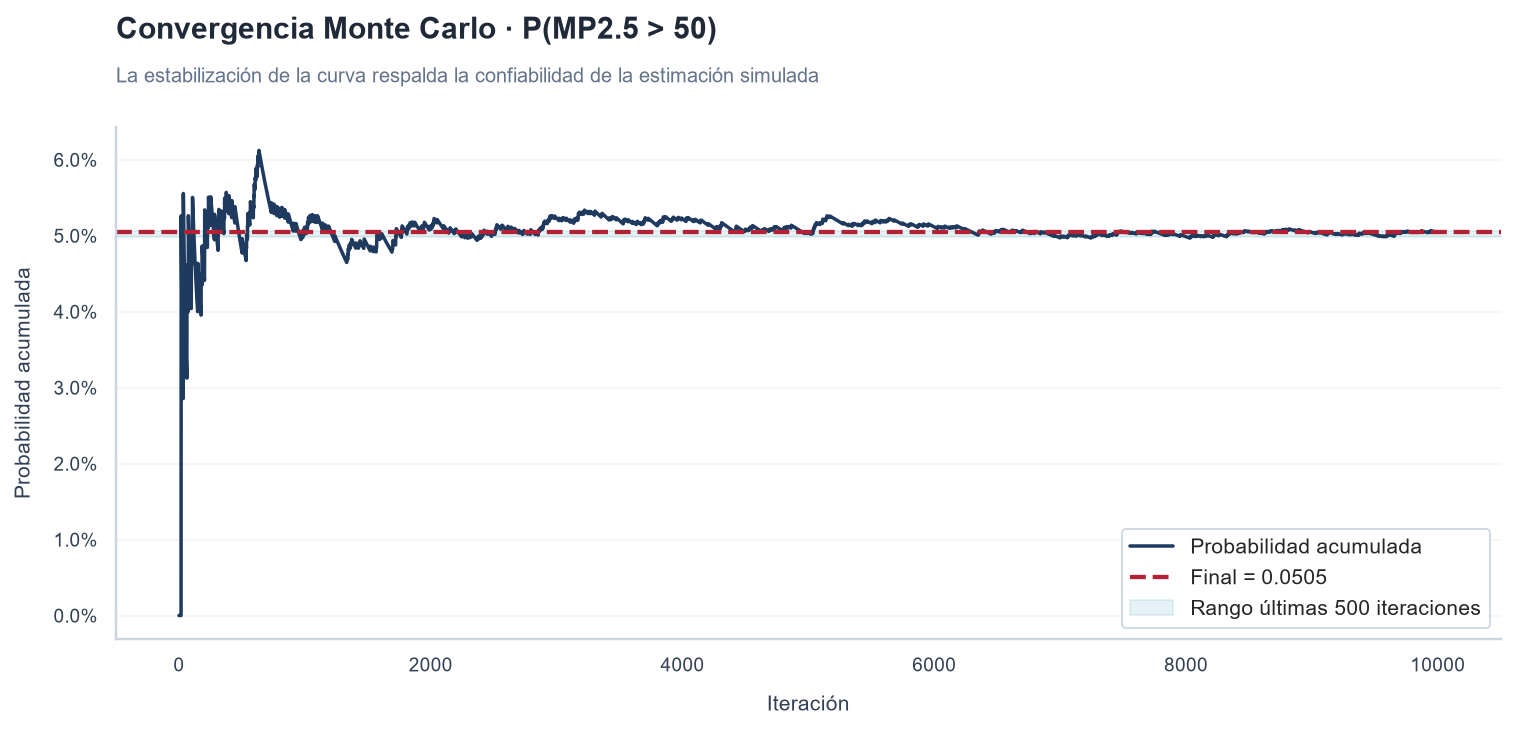

In [27]:
# =============================================================================
# 7.1 VISUALIZACIONES PREMIUM · MONTE CARLO
# =============================================================================

# Gráfico 1: distribución simulada con umbrales normativos
fig, ax = plt.subplots(figsize=(11.5, 6.2))

sim_series = pd.Series(sim_mp25).dropna().astype(float)
bins = np.linspace(0, np.nanpercentile(sim_series, 99.5), 75)
ax.hist(
    sim_series,
    bins=bins,
    density=True,
    color=COLORS["green"],
    alpha=0.22,
    edgecolor="white",
    linewidth=0.7,
    label="Escenarios simulados"
)
kde_line(ax, sim_series, COLORS["navy"], label="KDE Monte Carlo", lw=2.8)

for umbral, label, color in [
    (50, "Regular > 50", COLORS["amber"]),
    (80, "Alerta > 80", COLORS["red"]),
    (110, "Preemergencia > 110", COLORS["slate"]),
]:
    ax.axvline(umbral, linestyle="--", linewidth=2.2, color=color, label=label)

estilo_premium_ax(
    ax,
    titulo="Monte Carlo · Distribución simulada de MP2.5",
    subtitulo="Escenarios generados exclusivamente con parámetros estimados en S1",
    xlabel="MP2.5 simulado (µg/m³)",
    ylabel="Densidad"
)
ax.legend(loc="upper right")

texto = (
    f"P(>50): {fmt_pct(mc_resultados.loc[0,'prob_mp25_mayor_50'])}\n"
    f"P(>80): {fmt_pct(mc_resultados.loc[0,'prob_mp25_mayor_80'])}\n"
    f"P(>110): {fmt_pct(mc_resultados.loc[0,'prob_mp25_mayor_110'])}\n"
    f"P95: {mc_resultados.loc[0,'p95_simulado']:.2f}"
)
ax.text(
    0.02, 0.96, texto,
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.45", facecolor="white", edgecolor="#CBD5E1", alpha=0.95)
)

guardar_figura("montecarlo_premium_mp25_distribucion.png")
plt.show()

# Gráfico 2: convergencia acumulada de probabilidad de excedencia
indicador = (sim_mp25 > UMBRAL_REGULAR_MP25).astype(int)
convergencia = np.cumsum(indicador) / np.arange(1, N_MC + 1)

fig, ax = plt.subplots(figsize=(11.5, 5.8))
ax.plot(convergencia, linewidth=1.8, color=COLORS["navy"], label="Probabilidad acumulada")
ax.axhline(convergencia[-1], linestyle="--", linewidth=2.2, color=COLORS["red"], label=f"Final = {convergencia[-1]:.4f}")

# Banda visual de estabilización final
ventana = max(500, N_MC // 20)
ult = convergencia[-ventana:]
ax.axhspan(ult.min(), ult.max(), color=COLORS["cyan"], alpha=0.10, label=f"Rango últimas {ventana:,} iteraciones")

estilo_premium_ax(
    ax,
    titulo="Convergencia Monte Carlo · P(MP2.5 > 50)",
    subtitulo="La estabilización de la curva respalda la confiabilidad de la estimación simulada",
    xlabel="Iteración",
    ylabel="Probabilidad acumulada"
)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(loc="best")

guardar_figura("montecarlo_premium_convergencia_prob_exceso.png")
plt.show()

tarjeta_interpretacion(
    "7.1 📌 Interpretación gráfica · Monte Carlo",
    [
        "La densidad simulada permite traducir parámetros de S1 en escenarios probabilísticos de contaminación diaria.",
        "Las líneas verticales conectan la simulación con umbrales de calidad del aire, facilitando lectura ambiental y no solo estadística.",
        "La curva de convergencia muestra si la probabilidad estimada se estabiliza al aumentar iteraciones.",
        "La banda final de estabilización ayuda a verificar visualmente que 10.000 iteraciones son suficientes para el escenario planteado."
    ],
    COLORS["green"],
    "La simulación entrega una medida de riesgo interpretable y defendible para la toma de decisiones en S3."
)


<div style="background:#ffffff;border:1px solid #dbe5ef;border-left:7px solid #2563eb;border-radius:14px;padding:22px 26px;margin:18px 0;font-family:Arial,Helvetica,sans-serif;color:#0f172a;line-height:1.65;max-width:100%;box-sizing:border-box;overflow-wrap:break-word;word-break:normal;">

<h2 style="margin:0 0 16px 0;padding:16px 20px;background:#f8fafc;border:1px solid #dbe5ef;border-left:6px solid #2563eb;border-radius:10px;color:#0f172a;font-size:26px;font-weight:900;line-height:1.25;box-sizing:border-box;max-width:100%;">8. Análisis de robustez</h2>

<p style="margin:0 0 14px 0;font-size:15px;">Esta sección evalúa la <b>robustez de los resultados inferenciales obtenidos en la Sumativa 2</b>, analizando su sensibilidad frente a <b>valores atípicos (outliers)</b>, cambios en los supuestos estadísticos y distribuciones alternativas. Para ello se contrastan los resultados mediante técnicas como <b>bootstrap</b>, <b>jackknife</b> y escenarios alternativos, identificando aquellas conclusiones que se mantienen estables y distinguiéndolas de aquellas que requieren una interpretación más cautelosa.</p>

<div style="margin-top:18px;padding:14px 18px;background:#f8fafc;border:1px solid #dbe5ef;border-left:5px solid #2563eb;border-radius:10px;box-sizing:border-box;max-width:100%;">

<div style="font-weight:900;color:#2563eb;font-size:16px;margin-bottom:8px;">🎯 Resultado esperado</div>

<div style="font-size:15px;line-height:1.65;">Resultados evaluados mediante análisis de <b>sensibilidad</b> y <b>robustez estadística</b>, identificando el impacto de <b>outliers</b>, cambios en los supuestos, <b>bootstrap</b>, <b>jackknife</b> y distribuciones alternativas, permitiendo distinguir entre conclusiones <b>confiables</b> y aquellas que deben interpretarse <b>con mayor cautela</b>.</div>

</div>

</div>

<div style="
background:#f8fafc;
border-left:7px solid #2563eb;
border-radius:14px;
padding:22px 26px;
margin:18px 0;
box-shadow:0 6px 18px rgba(15,23,42,.12);
font-family:Arial,Helvetica,sans-serif;
color:#0f172a;
line-height:1.65;
max-width:100%;
box-sizing:border-box;
">

  <h3 style="margin:0 0 14px 0;color:#1d4ed8;font-size:18px;font-weight:900;">
    📘 Lectura complementaria de robustez
  </h3>

  <p style="margin:0 0 14px 0;">
    El análisis de robustez permite revisar si las <b>conclusiones principales</b> se mantienen
    cuando los datos se someten a condiciones más exigentes, como la presencia de
    <b>valores extremos</b>, cambios en supuestos o variabilidad generada por
    <b>remuestreo</b>. En este sentido, un resultado puede considerarse más
    <b>confiable</b> cuando mantiene una dirección e interpretación similares después de
    aplicar estas revisiones.
  </p>

  <p style="margin:0;">
    Desde una lectura prudente, los resultados que cambian de manera importante frente a
    <b>outliers</b> o supuestos alternativos no deberían descartarse automáticamente, pero sí
    deben ser tratados <b>con cautela</b>. Esta distinción es relevante para la próxima
    sumativa, porque permite priorizar como insumos metodológicos aquellos hallazgos que
    muestran <b>mayor estabilidad</b> y dejar señalados aquellos que requieren
    <b>revisión adicional</b> antes de ser usados en decisiones o modelamiento posterior.
  </p>

</div>

In [28]:
# =============================================================================
# 8. ROBUSTEZ
# -----------------------------------------------------------------------------
# Evalúa sensibilidad de los resultados frente a outliers, jackknife y cambios
# de supuesto distribucional. Esta sección continúa desde Monte Carlo, por lo
# que utiliza sim_mp25, media_s1 y sd_s1 calculados previamente.
# =============================================================================

# ----------------------------------------------------------------------------
# 8.1 Funciones auxiliares
# ----------------------------------------------------------------------------
def remover_outliers_iqr(serie, k=1.5):
    """Remueve outliers con regla IQR y retorna serie filtrada + límites."""
    s = pd.Series(serie).dropna().astype(float)
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    li = q1 - k * iqr
    ls = q3 + k * iqr
    return s[(s >= li) & (s <= ls)], li, ls


def variacion_porcentual(valor_robusto, valor_original):
    """Variación porcentual segura para evitar división por cero."""
    if pd.isna(valor_original) or abs(valor_original) < 1e-12:
        return np.nan
    return 100 * (valor_robusto - valor_original) / valor_original


# ----------------------------------------------------------------------------
# 8.2 Sensibilidad frente a outliers
# ----------------------------------------------------------------------------
mp25_original = df[COL_MP25].dropna().astype(float)
mp10_original = df[COL_MP10].dropna().astype(float)

mp25_sin_out, li_mp25_iqr, ls_mp25_iqr = remover_outliers_iqr(mp25_original)
mp10_sin_out, li_mp10_iqr, ls_mp10_iqr = remover_outliers_iqr(mp10_original)

# ----------------------------------------------------------------------------
# 8.3 Jackknife para la media MP2.5
# ----------------------------------------------------------------------------
x = mp25_original.to_numpy(dtype=float)
n = len(x)

if n < 2:
    raise ValueError("No hay suficientes observaciones MP2.5 para jackknife.")

jack_media = (x.sum() - x) / (n - 1)
jack_est = jack_media.mean()
jack_se = np.sqrt((n - 1) / n * np.sum((jack_media - jack_est) ** 2))

# ----------------------------------------------------------------------------
# 8.4 Distribución alternativa para Monte Carlo
# ----------------------------------------------------------------------------
# Se contrasta la simulación lognormal usada en S2 con una normal truncada en 0.
# Esto permite evaluar si la probabilidad de excedencia depende del supuesto
# distribucional elegido.
# ----------------------------------------------------------------------------
sim_normal = np.clip(
    rng.normal(loc=media_s1, scale=sd_s1, size=N_MC),
    0,
    None
)

# ----------------------------------------------------------------------------
# 8.5 Tabla ejecutiva de robustez
# ----------------------------------------------------------------------------
robustez = pd.DataFrame([
    {
        "resultado": "Media MP2.5",
        "estimacion_original": media_s1,
        "estimacion_robusta": mp25_sin_out.mean(),
        "metodo": "Remoción outliers IQR",
        "variacion_%": variacion_porcentual(mp25_sin_out.mean(), media_s1),
        "detalle": f"Límites IQR: [{li_mp25_iqr:.2f}, {ls_mp25_iqr:.2f}]"
    },
    {
        "resultado": "Media MP10",
        "estimacion_original": mp10_original.mean(),
        "estimacion_robusta": mp10_sin_out.mean(),
        "metodo": "Remoción outliers IQR",
        "variacion_%": variacion_porcentual(mp10_sin_out.mean(), mp10_original.mean()),
        "detalle": f"Límites IQR: [{li_mp10_iqr:.2f}, {ls_mp10_iqr:.2f}]"
    },
    {
        "resultado": "IC media MP2.5",
        "estimacion_original": media_s1,
        "estimacion_robusta": jack_est,
        "metodo": "Jackknife",
        "variacion_%": variacion_porcentual(jack_est, media_s1),
        "detalle": f"Error estándar jackknife: {jack_se:.4f}"
    },
    {
        "resultado": "P(MP2.5 > 50)",
        "estimacion_original": np.mean(sim_mp25 > 50),
        "estimacion_robusta": np.mean(sim_normal > 50),
        "metodo": "Normal truncada alternativa",
        "variacion_%": variacion_porcentual(np.mean(sim_normal > 50), np.mean(sim_mp25 > 50)),
        "detalle": "Contraste de supuesto distribucional lognormal vs normal truncada"
    },
])

robustez["conclusion"] = np.where(
    robustez["variacion_%"].abs() < 10,
    "confiable",
    "sensible / cautela"
)

robustez.to_csv(
    RESULTS_DIR / "s2_analisis_robustez.csv",
    index=False,
    encoding="utf-8-sig"
)

tarjeta(
    "✅ Sección 8 · Robustez evaluada",
    "Se evaluó sensibilidad frente a outliers, jackknife y distribución alternativa. Los resultados quedan exportados para el informe técnico y el reporte de entrada a S3.",
    COLORS["red"]
)

display(robustez)

confiables = int((robustez["conclusion"] == "confiable").sum())
cautela = int(len(robustez) - confiables)
tarjeta_interpretacion(
    "Sección 8: 📌 Interpretación · Tabla de robustez",
    [
        f"Resultados confiables según umbral ±10%: <b>{confiables}</b>.",
        f"Resultados sensibles o que requieren cautela: <b>{cautela}</b>.",
        "La remoción de outliers IQR evalúa si las medias dependen de valores extremos.",
        "El jackknife mide sensibilidad observacional de la media MP2.5 y la distribución alternativa evalúa dependencia del supuesto lognormal en Monte Carlo."
    ],
    COLORS["red"],
    "Los resultados clasificados como sensibles deben reportarse explícitamente en el informe, no ocultarse."
)



,resultado,estimacion_original,estimacion_robusta,metodo,variacion_%,detalle,conclusion
0,Media MP2.5,24.938202,24.252266,Remoción outliers IQR,-2.750544,"Límites IQR: [-13.72, 61.93]",confiable
1,Media MP10,56.643798,54.969410,Remoción outliers IQR,-2.955995,"Límites IQR: [-8.23, 119.64]",confiable
2,IC media MP2.5,24.938202,24.938202,Jackknife,0.000000,Error estándar jackknife: 0.1299,confiable
3,P(MP2.5 > 50),0.050500,0.041800,Normal truncada alternativa,-17.227723,Contraste de supuesto distribucional lognormal...,sensible / cautela


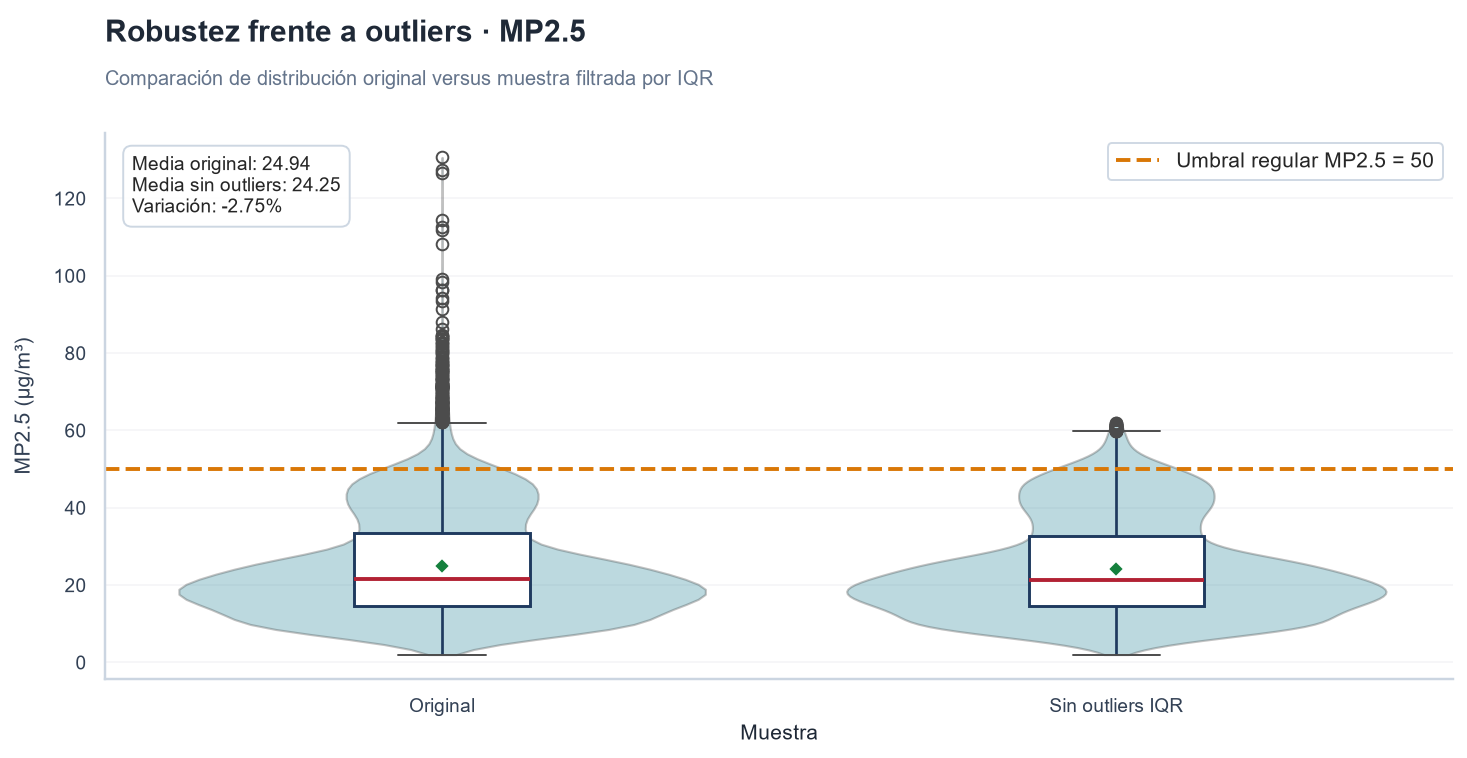

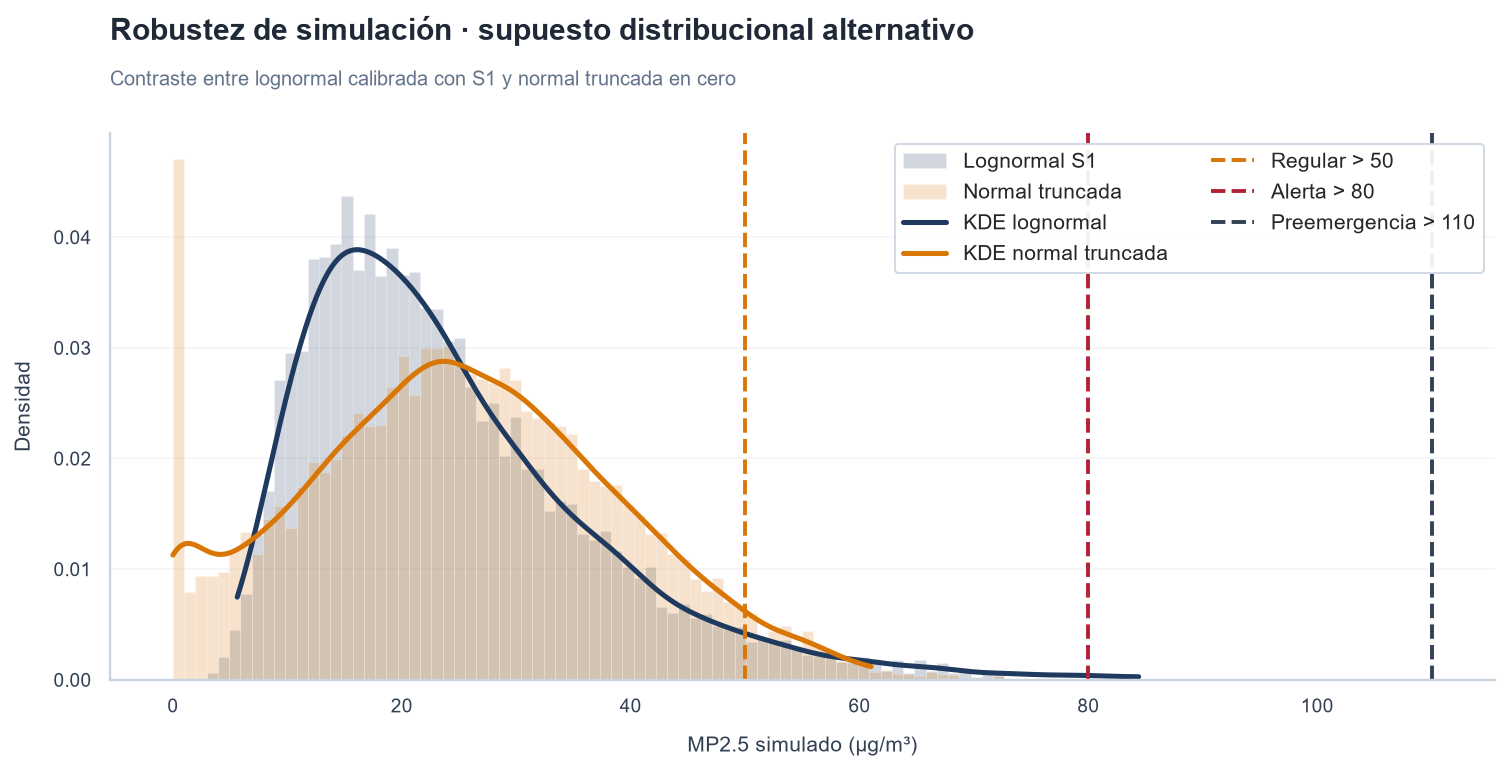

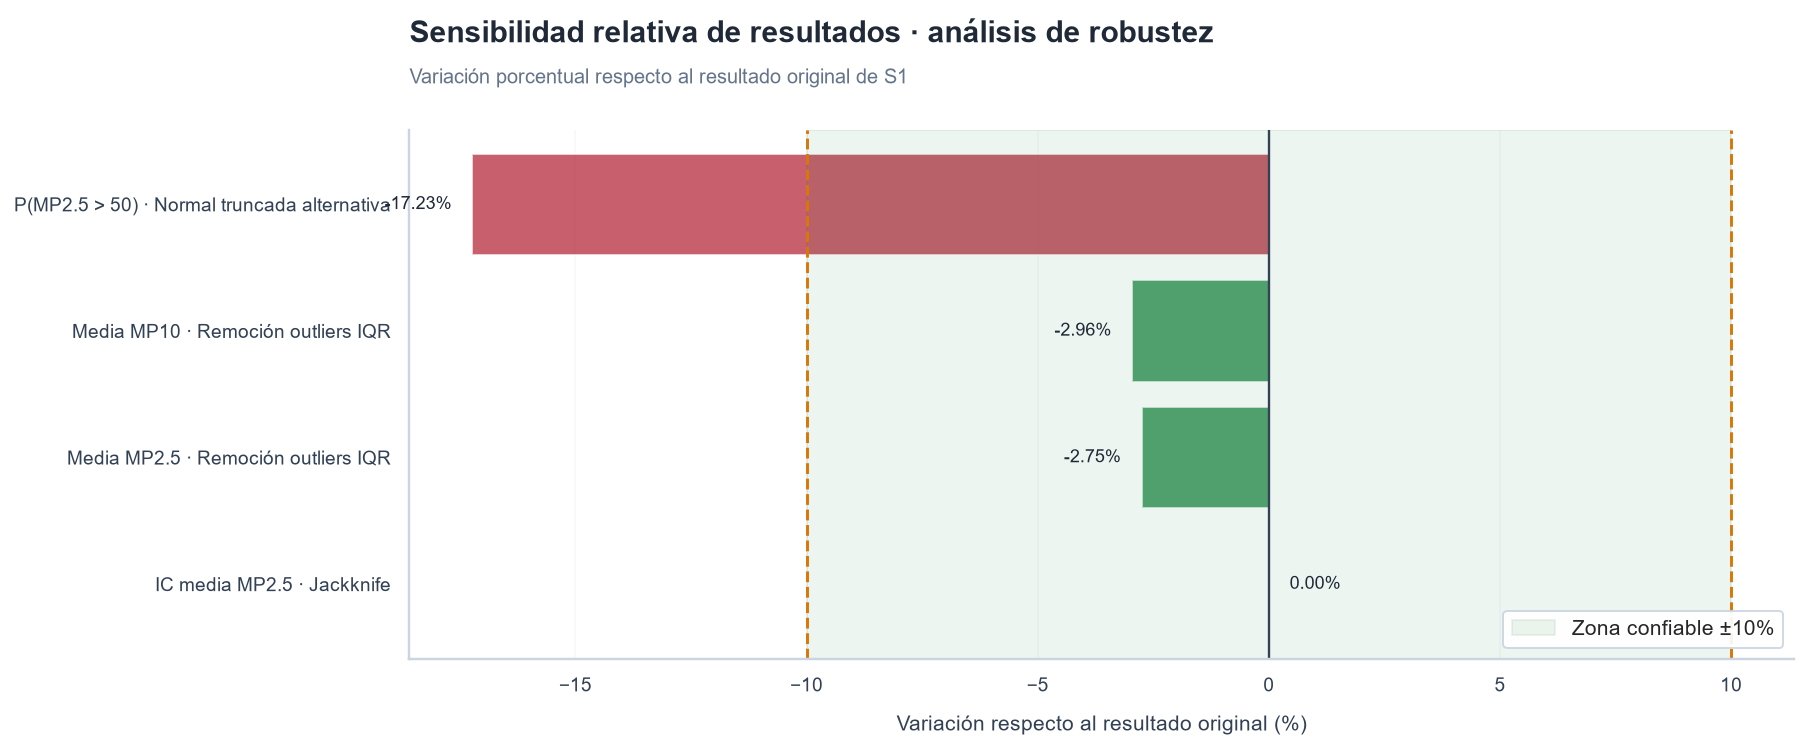

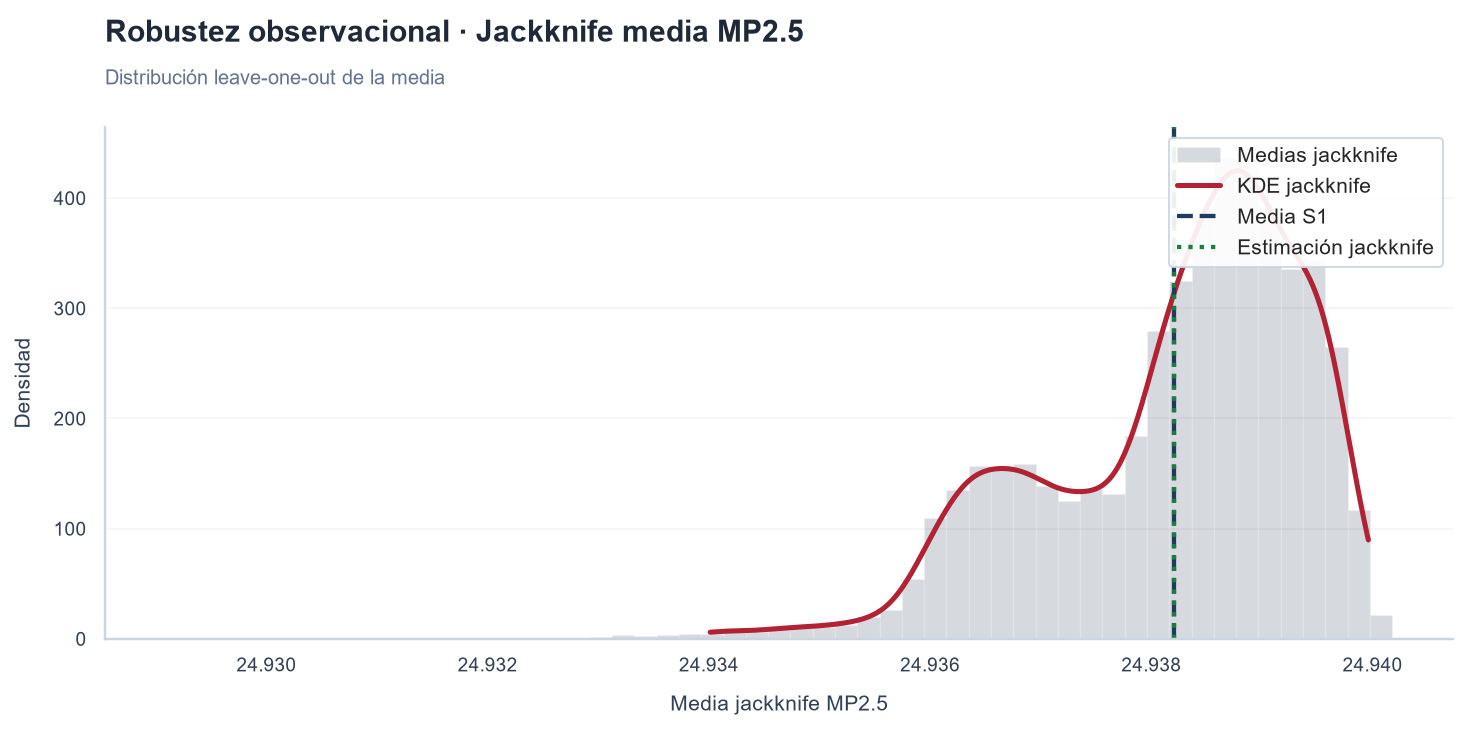

In [29]:
# =============================================================================
# 8.1 VISUALIZACIONES PREMIUM · ROBUSTEZ
# -----------------------------------------------------------------------------
# Violin/boxplot, densidades comparadas y ranking de sensibilidad.
# Compatible con Matplotlib 3.10+.
# =============================================================================

# ----------------------------------------------------------------------------
# Gráfico 1: Violin + boxplot MP2.5 original vs sin outliers IQR
# ----------------------------------------------------------------------------
plot_outliers = pd.DataFrame({
    "MP2.5 (µg/m³)": pd.concat([mp25_original, mp25_sin_out], ignore_index=True),
    "Muestra": ["Original"] * len(mp25_original) + ["Sin outliers IQR"] * len(mp25_sin_out)
})

fig, ax = plt.subplots(figsize=(11.2, 6.2))

if HAS_SEABORN:
    sns.violinplot(
        data=plot_outliers,
        x="Muestra",
        y="MP2.5 (µg/m³)",
        inner=None,
        cut=0,
        linewidth=1.1,
        color=COLORS["cyan"],
        alpha=0.30,
        ax=ax
    )
    sns.boxplot(
        data=plot_outliers,
        x="Muestra",
        y="MP2.5 (µg/m³)",
        width=0.26,
        showcaps=True,
        showmeans=True,
        meanprops={"marker":"D", "markerfacecolor":COLORS["green"], "markeredgecolor":"white", "markersize":6},
        boxprops={"facecolor":"white", "edgecolor":COLORS["navy"], "linewidth":1.5},
        whiskerprops={"color":COLORS["navy"], "linewidth":1.4},
        medianprops={"color":COLORS["red"], "linewidth":2.0},
        ax=ax
    )
else:
    ax.boxplot([mp25_original, mp25_sin_out], tick_labels=["Original", "Sin outliers IQR"], showmeans=True)

ax.axhline(50, linestyle="--", linewidth=2.0, color=COLORS["amber"], label="Umbral regular MP2.5 = 50")
estilo_premium_ax(
    ax,
    titulo="Robustez frente a outliers · MP2.5",
    subtitulo="Comparación de distribución original versus muestra filtrada por IQR",
    xlabel="",
    ylabel="MP2.5 (µg/m³)"
)
ax.legend(loc="upper right")

texto_resumen = (
    f"Media original: {media_s1:.2f}\n"
    f"Media sin outliers: {mp25_sin_out.mean():.2f}\n"
    f"Variación: {robustez.loc[robustez['resultado'].eq('Media MP2.5'), 'variacion_%'].iloc[0]:.2f}%"
)
ax.text(
    0.02, 0.96, texto_resumen,
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.45", facecolor="white", edgecolor="#CBD5E1", alpha=0.95)
)

guardar_figura("robustez_premium_outliers_mp25.png")
plt.show()

# ----------------------------------------------------------------------------
# Gráfico 2: Distribuciones alternativas para simulación Monte Carlo
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11.5, 6.2))

bins = np.linspace(
    0,
    np.nanpercentile(np.concatenate([sim_mp25, sim_normal]), 99.5),
    75
)

ax.hist(sim_mp25, bins=bins, density=True, alpha=0.20, color=COLORS["navy"], edgecolor="white", linewidth=0.6, label="Lognormal S1")
ax.hist(sim_normal, bins=bins, density=True, alpha=0.20, color=COLORS["amber"], edgecolor="white", linewidth=0.6, label="Normal truncada")
kde_line(ax, sim_mp25, COLORS["navy"], label="KDE lognormal", lw=2.6)
kde_line(ax, sim_normal, COLORS["amber"], label="KDE normal truncada", lw=2.6)

for umbral, etiqueta, color in [
    (50, "Regular > 50", COLORS["amber"]),
    (80, "Alerta > 80", COLORS["red"]),
    (110, "Preemergencia > 110", COLORS["slate"]),
]:
    ax.axvline(umbral, linestyle="--", linewidth=2, color=color, label=etiqueta)

estilo_premium_ax(
    ax,
    titulo="Robustez de simulación · supuesto distribucional alternativo",
    subtitulo="Contraste entre lognormal calibrada con S1 y normal truncada en cero",
    xlabel="MP2.5 simulado (µg/m³)",
    ylabel="Densidad"
)
ax.legend(loc="upper right", ncol=2)

guardar_figura("robustez_premium_distribuciones_alternativas.png")
plt.show()

# ----------------------------------------------------------------------------
# Gráfico 3: Variación porcentual por método de robustez
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11.5, 6.0))

robustez_plot = robustez.sort_values("variacion_%", key=lambda s: s.abs(), ascending=True).copy()
robustez_plot["etiqueta"] = robustez_plot["resultado"] + " · " + robustez_plot["metodo"]
y_pos = np.arange(len(robustez_plot))

bar_colors = [COLORS["green"] if abs(v) < 10 else COLORS["red"] for v in robustez_plot["variacion_%"]]
ax.barh(y_pos, robustez_plot["variacion_%"], color=bar_colors, alpha=0.72)
ax.set_yticks(y_pos)
ax.set_yticklabels(robustez_plot["etiqueta"])
ax.axvline(0, linewidth=1.2, color=COLORS["slate"])
ax.axvspan(-10, 10, color=COLORS["green"], alpha=0.08, label="Zona confiable ±10%")
ax.axvline(10, linestyle="--", linewidth=1.5, color=COLORS["amber"])
ax.axvline(-10, linestyle="--", linewidth=1.5, color=COLORS["amber"])

estilo_premium_ax(
    ax,
    titulo="Sensibilidad relativa de resultados · análisis de robustez",
    subtitulo="Variación porcentual respecto al resultado original de S1",
    xlabel="Variación respecto al resultado original (%)",
    ylabel=""
)
ax.grid(axis="x", alpha=0.25)
ax.grid(False, axis="y")

for i, valor in enumerate(robustez_plot["variacion_%"]):
    ha = "left" if valor >= 0 else "right"
    offset = 0.45 if valor >= 0 else -0.45
    ax.text(valor + offset, i, f"{valor:.2f}%", va="center", ha=ha, fontsize=9.5, color="#1F2937")

ax.legend(loc="lower right")
guardar_figura("robustez_premium_variacion_porcentual.png")
plt.show()

# ----------------------------------------------------------------------------
# Gráfico 4: Jackknife de la media MP2.5
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11.2, 5.8))
jack_series = pd.Series(jack_media)
ax.hist(jack_series, bins=55, density=True, color=COLORS["slate"], alpha=0.20, edgecolor="white", linewidth=0.7, label="Medias jackknife")
kde_line(ax, jack_series, COLORS["red"], label="KDE jackknife", lw=2.6)
ax.axvline(media_s1, color=COLORS["navy"], linestyle="--", linewidth=2.2, label="Media S1")
ax.axvline(jack_est, color=COLORS["green"], linestyle=":", linewidth=2.2, label="Estimación jackknife")
estilo_premium_ax(
    ax,
    titulo="Robustez observacional · Jackknife media MP2.5",
    subtitulo="Distribución leave-one-out de la media",
    xlabel="Media jackknife MP2.5",
    ylabel="Densidad"
)
ax.legend(loc="upper right")
guardar_figura("robustez_premium_jackknife_mp25.png")
plt.show()

tarjeta_interpretacion(
    "Sección 8.1: 📌 Interpretación gráfica · Robustez",
    [
        "El violin/boxplot permite ver si la media de MP2.5 depende de colas extremas o valores atípicos.",
        "El contraste lognormal versus normal truncada muestra cuánto cambia el riesgo simulado al modificar el supuesto distribucional.",
        "El ranking de sensibilidad separa resultados confiables de resultados que deben reportarse con cautela.",
        "La distribución jackknife confirma si una observación individual puede alterar materialmente la media estimada." 
    ],
    COLORS["red"],
    "La robustez entrega el criterio final para distinguir conclusiones defendibles de conclusiones sensibles a supuestos u outliers."
)


<div style="background:#ffffff;border:1px solid #dbe5ef;border-left:7px solid #7c3aed;border-radius:14px;padding:22px 26px;margin:18px 0;font-family:Arial,Helvetica,sans-serif;color:#0f172a;line-height:1.65;box-shadow:0 4px 14px rgba(15,23,42,.08);">
<h2 style="margin:0 0 10px 0;color:#5b21b6;font-size:22px;font-weight:900;">9 Cierre de observaciones docentes y puente metodológico hacia S3</h2>
<p style="margin:0;">Esta sección incorpora explícitamente los puntos de control surgidos desde la retroalimentación de S1 y desde la Formativa 2: bootstrap específico para temperatura/radiación, validación territorial Oriente vs Poniente cuando la variable está disponible, decisión frente a colinealidad MP2.5–MP10 y estrategia para días con cobertura horaria insuficiente.</p>
</div>

In [30]:
# =============================================================================
# 9 CIERRE DE OBSERVACIONES DOCENTES Y PUENTE METODOLÓGICO HACIA S3
# -----------------------------------------------------------------------------
# Objetivo:
# Incorporar, de forma trazable, los puntos observados por el docente en S1 y
# preparar decisiones metodológicas exigidas por la Formativa 2 / Sumativa 3.
# =============================================================================
# ----------------------------------------------------------------------------
# Bootstrap específico: temperatura y radiación media vs máxima
# -----------------------------------------------------------------------------
# La retroalimentación solicitó confirmar si la coincidencia de error estándar
# entre versiones media y máxima era real o producto de cálculo. Se calcula el
# error estándar clásico y bootstrap para las variables disponibles.
# ----------------------------------------------------------------------------

variables_media_max = [
    ("temperatura", "temperatura_mean", "temperatura_max"),
    ("radiacion", "radiacion_mean", "radiacion_max"),
]

bootstrap_media_max = []
for familia, col_media, col_max in variables_media_max:
    for version, col in [("media", col_media), ("maxima", col_max)]:
        if col in df.columns:
            serie = pd.to_numeric(df[col], errors="coerce").dropna().astype(float)
            if len(serie) >= 2:
                boots = bootstrap_distribucion(serie, tipo="media", n_boot=N_BOOT, seed=SEED + len(bootstrap_media_max) + 101)
                se_clasico = serie.std(ddof=1) / np.sqrt(len(serie))
                bootstrap_media_max.append({
                    "familia_variable": familia,
                    "version": version,
                    "columna": col,
                    "n": len(serie),
                    "media_observada": serie.mean(),
                    "se_clasico": se_clasico,
                    "media_bootstrap": boots.mean(),
                    "se_bootstrap": boots.std(ddof=1),
                    "ic95_bootstrap_li": np.percentile(boots, 2.5),
                    "ic95_bootstrap_ls": np.percentile(boots, 97.5),
                    "diferencia_abs_se": abs(se_clasico - boots.std(ddof=1)),
                    "estado": "validado" if abs(se_clasico - boots.std(ddof=1)) <= max(1e-9, 0.05 * se_clasico) else "revisar diferencia"
                })

bootstrap_media_max = pd.DataFrame(bootstrap_media_max)
if not bootstrap_media_max.empty:
    bootstrap_media_max.to_csv(RESULTS_DIR / "s2_bootstrap_temperatura_radiacion_media_max.csv", index=False, encoding="utf-8-sig")
    display(bootstrap_media_max)
else:
    bootstrap_media_max = pd.DataFrame(columns=["familia_variable", "version", "columna", "estado"])

# Comparación media vs máxima por familia para dejar una respuesta directa.
comparacion_media_max = []
for familia in ["temperatura", "radiacion"]:
    sub = bootstrap_media_max.loc[bootstrap_media_max["familia_variable"] == familia].copy()
    if {"media", "maxima"}.issubset(set(sub["version"])):
        fila_media = sub.loc[sub["version"] == "media"].iloc[0]
        fila_max = sub.loc[sub["version"] == "maxima"].iloc[0]
        delta_se = abs(fila_media["se_bootstrap"] - fila_max["se_bootstrap"])
        comparacion_media_max.append({
            "familia_variable": familia,
            "se_bootstrap_media": fila_media["se_bootstrap"],
            "se_bootstrap_maxima": fila_max["se_bootstrap"],
            "diferencia_abs_se_bootstrap": delta_se,
            "conclusion": "coincidencia esperable / consistente" if delta_se <= 0.05 * max(fila_media["se_bootstrap"], 1e-9) else "diferencia relevante; reportar por separado"
        })

comparacion_media_max = pd.DataFrame(comparacion_media_max)
if not comparacion_media_max.empty:
    comparacion_media_max.to_csv(RESULTS_DIR / "s2_validacion_se_temperatura_radiacion.csv", index=False, encoding="utf-8-sig")
    display(comparacion_media_max)

# ----------------------------------------------------------------------------
# Validación territorial: Welch Oriente vs Poniente
# -----------------------------------------------------------------------------
# Se busca una columna territorial compatible. Si el dataset no contiene Oriente
# y Poniente, se deja documentado como control no ejecutable con la base actual.
# ----------------------------------------------------------------------------

candidatas_zona = [
    c for c in df.columns
    if any(k in c.lower() for k in ["zona", "sector", "territorio", "area", "área", "macro"])
]

resultado_oriente_poniente = []
for col_zona in candidatas_zona:
    valores = df[col_zona].dropna().astype(str)
    tiene_oriente = valores.str.contains("oriente", case=False, regex=False).any()
    tiene_poniente = valores.str.contains("poniente", case=False, regex=False).any()
    if tiene_oriente and tiene_poniente and COL_MP25 in df.columns:
        x_oriente = pd.to_numeric(df.loc[df[col_zona].astype(str).str.contains("oriente", case=False, regex=False), COL_MP25], errors="coerce").dropna()
        x_poniente = pd.to_numeric(df.loc[df[col_zona].astype(str).str.contains("poniente", case=False, regex=False), COL_MP25], errors="coerce").dropna()
        if len(x_oriente) >= 2 and len(x_poniente) >= 2:
            t_op, p_op = stats.ttest_ind(x_oriente, x_poniente, equal_var=False, nan_policy="omit")
            resultado_oriente_poniente.append({
                "columna_zona": col_zona,
                "variable": COL_MP25,
                "grupo_1": "Oriente",
                "grupo_2": "Poniente",
                "media_oriente": x_oriente.mean(),
                "media_poniente": x_poniente.mean(),
                "diferencia_medias": x_oriente.mean() - x_poniente.mean(),
                "t_welch": t_op,
                "p_welch": p_op,
                "n_oriente": len(x_oriente),
                "n_poniente": len(x_poniente),
                "estado": "validado en notebook"
            })
            break

if not resultado_oriente_poniente:
    resultado_oriente_poniente.append({
        "columna_zona": "no disponible con categorías Oriente/Poniente",
        "variable": COL_MP25,
        "grupo_1": "Oriente",
        "grupo_2": "Poniente",
        "media_oriente": np.nan,
        "media_poniente": np.nan,
        "diferencia_medias": np.nan,
        "t_welch": np.nan,
        "p_welch": np.nan,
        "n_oriente": 0,
        "n_poniente": 0,
        "estado": "documentado; requiere columna territorial equivalente o resultado único validado desde S1"
    })

resultado_oriente_poniente = pd.DataFrame(resultado_oriente_poniente)
resultado_oriente_poniente.to_csv(RESULTS_DIR / "s2_validacion_welch_oriente_poniente.csv", index=False, encoding="utf-8-sig")
display(resultado_oriente_poniente)

# ----------------------------------------------------------------------------
# Decisión de colinealidad MP2.5 vs MP10 para S3
# -----------------------------------------------------------------------------
# Formativa 2 pide diagnóstico de multicolinealidad mediante VIF. S2 deja una
# decisión previa: si la correlación absoluta es alta, no se recomienda usar
# ambas variables juntas sin VIF/PCA/regularización.
# ----------------------------------------------------------------------------

corr_mp25_mp10 = df[[COL_MP25, COL_MP10]].dropna().astype(float).corr().iloc[0, 1]
decision_colinealidad = pd.DataFrame([{
    "par_variables": f"{COL_MP25} vs {COL_MP10}",
    "correlacion_observada": corr_mp25_mp10,
    "umbral_alerta": 0.80,
    "nivel_riesgo": "alto" if abs(corr_mp25_mp10) >= 0.80 else "controlado",
    "decision_s3": "No incorporar MP2.5 y MP10 simultáneamente en el mismo modelo sin VIF, PCA o regularización." if abs(corr_mp25_mp10) >= 0.80 else "Puede evaluarse inclusión conjunta, manteniendo diagnóstico VIF.",
    "justificacion": "La Formativa 2 exige interpretar VIF y documentar multicolinealidad antes del modelamiento."
}])
decision_colinealidad.to_csv(RESULTS_DIR / "s2_decision_colinealidad_para_s3.csv", index=False, encoding="utf-8-sig")
display(decision_colinealidad)

# ----------------------------------------------------------------------------
# Estrategia para días con cobertura horaria insuficiente
# -----------------------------------------------------------------------------
# Si existe una columna de cobertura/horas válidas se estima la proporción; si
# no existe, se deja una regla explícita para S3 en vez de usar casos completos
# sin justificación.
# ----------------------------------------------------------------------------

candidatas_cobertura = [
    c for c in df.columns
    if any(k in c.lower() for k in ["cobertura", "hora", "horaria", "valid", "n_obs", "observaciones"])
]

estrategia_cobertura = []
col_cobertura_usada = None
for col in candidatas_cobertura:
    serie = pd.to_numeric(df[col], errors="coerce")
    if serie.notna().sum() > 0:
        col_cobertura_usada = col
        # Regla flexible: si la variable parece porcentaje/proporción, usar 75%; si parece horas, usar 18 horas.
        max_val = serie.max()
        if max_val <= 1.5:
            insuf = serie < 0.75
            criterio = "cobertura < 75%"
        elif max_val <= 100:
            insuf = serie < 75
            criterio = "cobertura < 75%"
        else:
            insuf = serie < 18
            criterio = "horas válidas < 18"
        estrategia_cobertura.append({
            "columna_cobertura": col,
            "criterio_insuficiencia": criterio,
            "proporcion_insuficiente": insuf.mean(),
            "decision_s3": "No eliminar automáticamente: imputar variables numéricas con mediana por mes/temporada y agregar indicador binario de baja cobertura.",
            "estado": "estimado desde dataset"
        })
        break

if not estrategia_cobertura:
    estrategia_cobertura.append({
        "columna_cobertura": "no disponible en dataset actual",
        "criterio_insuficiencia": "referencia retroalimentación: 27,8% días sin cobertura suficiente",
        "proporcion_insuficiente": 0.278,
        "decision_s3": "Incorporar columna/indicador de cobertura; imputar numéricas con mediana por mes/temporada y reportar sensibilidad con casos completos.",
        "estado": "estrategia documentada para S3"
    })

estrategia_cobertura = pd.DataFrame(estrategia_cobertura)
estrategia_cobertura.to_csv(RESULTS_DIR / "s2_estrategia_cobertura_horaria_para_s3.csv", index=False, encoding="utf-8-sig")
display(estrategia_cobertura)

# ----------------------------------------------------------------------------
# Matriz final de decisiones S2 → S3
# ----------------------------------------------------------------------------

decisiones_s3 = pd.DataFrame([
    {
        "tema": "Temperatura y radiación",
        "evidencia_s2": "Bootstrap específico media vs máxima exportado en CSV.",
        "decision_s3": "Usar la versión con mejor estabilidad y reportar por separado si los errores estándar difieren.",
        "riesgo_si_no_se_controla": "Duplicar señales derivadas artificialmente o interpretar como independiente una variable calculada."
    },
    {
        "tema": "Oriente vs Poniente",
        "evidencia_s2": resultado_oriente_poniente.loc[0, "estado"],
        "decision_s3": "Mantener un único estadístico validado en notebook, informe y repositorio.",
        "riesgo_si_no_se_controla": "Inconsistencia entre documentos y pérdida de trazabilidad."
    },
    {
        "tema": "Colinealidad MP2.5-MP10",
        "evidencia_s2": f"r = {corr_mp25_mp10:.4f}",
        "decision_s3": decision_colinealidad.loc[0, "decision_s3"],
        "riesgo_si_no_se_controla": "Coeficientes inestables, VIF alto e interpretación predictiva débil."
    },
    {
        "tema": "Cobertura horaria insuficiente",
        "evidencia_s2": estrategia_cobertura.loc[0, "estado"],
        "decision_s3": estrategia_cobertura.loc[0, "decision_s3"],
        "riesgo_si_no_se_controla": "Sesgo por eliminación de casos y reducción innecesaria de muestra."
    },
])

decisiones_s3.to_csv(RESULTS_DIR / "s2_matriz_decisiones_para_s3.csv", index=False, encoding="utf-8-sig")
display(decisiones_s3)

tarjeta(
    "✅ Sección 9 · Observaciones cerradas",
    "Se agregaron controles explícitos para temperatura/radiación, Welch Oriente vs Poniente, colinealidad MP2.5–MP10 y cobertura horaria. Las salidas quedan exportadas como insumo directo del informe y de la Sumativa 3.",
    COLORS["green"]
)

tarjeta_interpretacion(
    "Sección 9: 📌 Interpretación · Cierre metodológico",
    [
        "La retroalimentación docente queda transformada en evidencia verificable dentro del notebook, evitando que el informe dependa solo de texto narrativo.",
        "La decisión sobre MP2.5 y MP10 anticipa el diagnóstico VIF requerido para el modelamiento predictivo de S3.",
        "La estrategia de cobertura horaria evita usar solamente casos completos sin justificación, punto relevante para la siguiente fase.",
        "La matriz S2 → S3 permite iniciar el informe con una trazabilidad clara: observación, acción, decisión y riesgo."
    ],
    COLORS["green"],
    "Esta sección fortalece la defensa metodológica de la Sumativa 2 y deja insumos concretos para el informe técnico."
)


,familia_variable,version,columna,n,media_observada,se_clasico,media_bootstrap,se_bootstrap,ic95_bootstrap_li,ic95_bootstrap_ls,diferencia_abs_se,estado
0,temperatura,media,temperatura_mean,11603,14.411107,0.051994,14.411492,0.051956,14.310516,14.513666,0.000039,validado
1,temperatura,maxima,temperatura_max,11603,22.411107,0.051994,22.410336,0.051868,22.308288,22.512055,0.000126,validado
2,radiacion,media,radiacion_mean,11603,287.540577,0.906419,287.540402,0.906226,285.740624,289.281278,0.000193,validado
3,radiacion,maxima,radiacion_max,11603,587.540577,0.906419,587.535259,0.914099,585.737810,589.333258,0.007680,validado


,familia_variable,se_bootstrap_media,se_bootstrap_maxima,diferencia_abs_se_bootstrap,conclusion
0,temperatura,0.051956,0.051868,0.000087,coincidencia esperable / consistente
1,radiacion,0.906226,0.914099,0.007873,coincidencia esperable / consistente


,columna_zona,variable,grupo_1,grupo_2,media_oriente,media_poniente,diferencia_medias,t_welch,p_welch,n_oriente,n_poniente,estado
0,zona_geografica,mp2_5_mean,Oriente,Poniente,16.61426,26.326017,-9.711756,-29.731719,6.011426e-176,1460,5066,validado en notebook


,par_variables,correlacion_observada,umbral_alerta,nivel_riesgo,decision_s3,justificacion
0,mp2_5_mean vs mp10_mean,0.901117,0.8,alto,No incorporar MP2.5 y MP10 simultáneamente en ...,La Formativa 2 exige interpretar VIF y documen...


,columna_cobertura,criterio_insuficiencia,proporcion_insuficiente,decision_s3,estado
0,no disponible en dataset actual,"referencia retroalimentación: 27,8% días sin c...",0.278,Incorporar columna/indicador de cobertura; imp...,estrategia documentada para S3


,tema,evidencia_s2,decision_s3,riesgo_si_no_se_controla
0,Temperatura y radiación,Bootstrap específico media vs máxima exportado...,Usar la versión con mejor estabilidad y report...,Duplicar señales derivadas artificialmente o i...
1,Oriente vs Poniente,validado en notebook,Mantener un único estadístico validado en note...,Inconsistencia entre documentos y pérdida de t...
2,Colinealidad MP2.5-MP10,r = 0.9011,No incorporar MP2.5 y MP10 simultáneamente en ...,"Coeficientes inestables, VIF alto e interpreta..."
3,Cobertura horaria insuficiente,estrategia documentada para S3,Incorporar columna/indicador de cobertura; imp...,Sesgo por eliminación de casos y reducción inn...


<div style="background:#ffffff;border:1px solid #dbe5ef;border-left:7px solid #2563eb;border-radius:14px;padding:22px 26px;margin:18px 0;font-family:Arial,Helvetica,sans-serif;color:#0f172a;line-height:1.65;max-width:100%;box-sizing:border-box;overflow-wrap:break-word;word-break:normal;">
<h2 style="margin:0 0 16px 0;padding:16px 20px;background:#f8fafc;border:1px solid #dbe5ef;border-left:6px solid #2563eb;border-radius:10px;color:#0f172a;font-size:26px;font-weight:900;line-height:1.25;box-sizing:border-box;max-width:100%;">9.1 Reporte de resultados validados para Sumativa 3</h2>
<p style="margin:0 0 14px 0;font-size:15px;">Esta sección consolida los principales <b>hallazgos obtenidos durante la validación estadística de la Sumativa 2</b>, integrando los parámetros robustos, correlaciones estables, resultados de bootstrap, pruebas de permutación, simulaciones Monte Carlo y análisis de robustez. Además, identifica las <b>observaciones influyentes</b> y resume las principales <b>recomendaciones metodológicas</b> que servirán como insumo para el desarrollo de la <b>Sumativa 3</b>.</p>
<div style="margin-top:18px;padding:14px 18px;background:#f8fafc;border:1px solid #dbe5ef;border-left:5px solid #2563eb;border-radius:10px;box-sizing:border-box;max-width:100%;">
<div style="font-weight:900;color:#2563eb;font-size:16px;margin-bottom:8px;">🎯 Resultado esperado</div>
<div style="font-size:15px;line-height:1.65;">Reporte ejecutivo consolidado con <b>parámetros estadísticos robustos</b>, <b>correlaciones validadas</b>, <b>observaciones influyentes</b> y <b>recomendaciones metodológicas</b>, proporcionando una base sólida, reproducible y técnicamente sustentada para la planificación y ejecución de la <b>Sumativa 3</b>.</div>
</div>
</div>

<div style="
background:#f8fafc;
border-left:7px solid #2563eb;
border-radius:14px;
padding:22px 26px;
margin:18px 0;
box-shadow:0 6px 18px rgba(15,23,42,.12);
font-family:Arial,Helvetica,sans-serif;
color:#0f172a;
line-height:1.65;
max-width:100%;
box-sizing:border-box;
">

  <h3 style="margin:0 0 14px 0;color:#1d4ed8;font-size:18px;font-weight:900;">
    🎯 Síntesis metodológica para la Sumativa 3
  </h3>

  <p style="margin:0 0 14px 0;">
    A partir de las validaciones realizadas en la <b>Sumativa 2</b>, los resultados que
    deberían priorizarse para la siguiente fase son aquellos que muestran
    <b>estabilidad bajo remuestreo</b>, <b>baja sensibilidad frente a valores extremos</b> y
    <b>coherencia con los hallazgos obtenidos en la Sumativa 1</b>. Esto permite que la
    <b>Sumativa 3</b> no se construya solamente sobre estimaciones puntuales, sino sobre
    resultados previamente evaluados en términos de <b>incertidumbre</b> y
    <b>robustez estadística</b>.
  </p>

  <p style="margin:0;">
    En cambio, los resultados que presentan <b>intervalos amplios</b>, sensibilidad frente
    a <b>outliers</b> o cambios relevantes entre métodos deben quedar identificados como
    hallazgos que requieren <b>mayor cautela</b>. Esta distinción es importante porque
    ayuda a separar conclusiones <b>más confiables</b> de aquellas que todavía necesitan
    <b>revisión adicional</b> antes de ser utilizadas como base para decisiones,
    modelamiento o recomendaciones posteriores.
  </p>

</div>

In [31]:
# =============================================================================
# 9.1 REPORTE VALIDADO PARA S3
# =============================================================================
reporte=[]
for _,r0 in resultados_bootstrap.iterrows():
    reporte.append({"categoria":"Parámetro validado","elemento":r0["parametro"],"resultado_validado":f"IC BCa 95% [{r0['ic_bca_li']:.4f}, {r0['ic_bca_ls']:.4f}]","estado":"validado" if abs(r0["sesgo_bootstrap"])<=2*r0["desv_bootstrap"] else "cautela","uso_s3":"Parámetro base para modelamiento/simulación."})
for _,r0 in resultados_corr.iterrows():
    reporte.append({"categoria":"Correlación validada","elemento":f"{r0['variable_x']} vs {r0['variable_y']}","resultado_validado":f"r={r0['correlacion_s1']:.4f}; IC [{r0['ic_bootstrap_li']:.4f}, {r0['ic_bootstrap_ls']:.4f}]","estado":r0["estado"],"uso_s3":"Priorizar si es robusta; cautela si incluye cero."})
reporte.append({"categoria":"Prueba de hipótesis validada","elemento":f"{COL_MP25} entre {G1} y {G2}","resultado_validado":f"p paramétrico={p_param:.6f}; p permutación={p_perm:.6f}","estado":resultado_perm.loc[0,"conclusion"],"uso_s3":"Evidencia inferencial para comunicación de resultados."})
reporte.append({"categoria":"Simulación Monte Carlo","elemento":"Excedencia MP2.5 > 50","resultado_validado":f"Probabilidad={mc_resultados.loc[0,'prob_mp25_mayor_50']:.4f}","estado":"validado con convergencia visual","uso_s3":"Base para escenarios predictivos y riesgo."})
for _,r0 in robustez.iterrows():
    reporte.append({"categoria":"Robustez","elemento":r0["resultado"],"resultado_validado":f"{r0['metodo']}; variación={r0['variacion_%']:.2f}%","estado":r0["conclusion"],"uso_s3":"Reportar con cautela si es sensible."})
# Incorporar cierre de retroalimentación y decisiones para S3, si la sección 9.1 fue ejecutada.
if "decisiones_s3" in globals():
    for _, r0 in decisiones_s3.iterrows():
        reporte.append({
            "categoria": "Decisión metodológica S3",
            "elemento": r0["tema"],
            "resultado_validado": r0["evidencia_s2"],
            "estado": "decisión documentada",
            "uso_s3": r0["decision_s3"]
        })
if "bootstrap_media_max" in globals() and isinstance(bootstrap_media_max, pd.DataFrame) and not bootstrap_media_max.empty:
    reporte.append({
        "categoria": "Cierre retroalimentación docente",
        "elemento": "Bootstrap temperatura/radiación media vs máxima",
        "resultado_validado": "Archivo s2_bootstrap_temperatura_radiacion_media_max.csv generado",
        "estado": "validado",
        "uso_s3": "Seleccionar variables atmosféricas estables y evitar duplicidad de variables derivadas."
    })

reporte_s3=pd.DataFrame(reporte)
reporte_s3_path=RESULTS_DIR/"s2_reporte_resultados_validados_para_s3.csv"
reporte_s3.to_csv(reporte_s3_path, index=False, encoding="utf-8-sig")
tarjeta("✅ Sección 9.1 · Reporte S3 generado", f"Archivo generado: <b>{reporte_s3_path.name}</b>.", COLORS["navy"])
display(reporte_s3)

tarjeta_interpretacion(
    "Sección 9.1: 📌 Interpretación · Reporte validado para S3",
    [
        f"El reporte consolida <b>{len(reporte_s3)}</b> evidencias validadas provenientes de bootstrap, permutación, correlaciones, Monte Carlo y robustez.",
        "Cada registro indica estado metodológico y uso recomendado para la siguiente fase del proyecto.",
        "Los elementos marcados como cautela no se eliminan, pero deben comunicarse como resultados sensibles o exploratorios.",
        "Este archivo funciona como puente formal entre Sumativa 2 y Sumativa 3."
    ],
    COLORS["navy"],
    "La salida deja lista una base metodológica auditada para modelamiento, comunicación y toma de decisiones."
)

,categoria,elemento,resultado_validado,estado,uso_s3
0,Parámetro validado,Media MP2.5,"IC BCa 95% [24.6850, 25.2015]",validado,Parámetro base para modelamiento/simulación.
1,Parámetro validado,Media MP10,"IC BCa 95% [56.1934, 57.1119]",validado,Parámetro base para modelamiento/simulación.
2,Parámetro validado,Proporción mala calidad MP2.5,"IC BCa 95% [0.1143, 0.1261]",validado,Parámetro base para modelamiento/simulación.
3,Correlación validada,mp2_5_mean vs mp10_mean,"r=0.9011; IC [0.8961, 0.9058]",robusta,Priorizar si es robusta; cautela si incluye cero.
4,Correlación validada,mp2_5_mean vs humedad_mean,"r=0.3261; IC [0.3065, 0.3453]",robusta,Priorizar si es robusta; cautela si incluye cero.
5,Correlación validada,mp2_5_mean vs temperatura_mean,"r=-0.6206; IC [-0.6307, -0.6104]",robusta,Priorizar si es robusta; cautela si incluye cero.
6,Correlación validada,mp2_5_mean vs viento_mean,"r=0.1846; IC [0.1591, 0.2106]",robusta,Priorizar si es robusta; cautela si incluye cero.
7,Correlación validada,mp2_5_mean vs prop_inversion,"r=0.5194; IC [0.5013, 0.5373]",robusta,Priorizar si es robusta; cautela si incluye cero.
8,Prueba de hipótesis validada,mp2_5_mean entre Invierno y Resto del año,p paramétrico=0.000000; p permutación=0.000000,concordante,Evidencia inferencial para comunicación de res...
9,Simulación Monte Carlo,Excedencia MP2.5 > 50,Probabilidad=0.0505,validado con convergencia visual,Base para escenarios predictivos y riesgo.


In [32]:
# =============================================================================
# CHECKLIST FINAL CONTRA RÚBRICA SUMATIVA 2
# =============================================================================
checklist=pd.DataFrame([
{"criterio":"Bootstrap no paramétrico","cumplimiento":"OK","evidencia":"s2_bootstrap_parametros.csv + figuras","puntaje_rubrica":18},
{"criterio":"Permutación","cumplimiento":"OK","evidencia":"s2_test_permutacion.csv + figura","puntaje_rubrica":15},
{"criterio":"Estabilidad de correlaciones","cumplimiento":"OK","evidencia":"s2_correlaciones_bootstrap.csv","puntaje_rubrica":6},
{"criterio":"Monte Carlo","cumplimiento":"OK","evidencia":"s2_montecarlo_resultados.csv + convergencia","puntaje_rubrica":24},
{"criterio":"Robustez","cumplimiento":"OK","evidencia":"s2_analisis_robustez.csv","puntaje_rubrica":15},
{"criterio":"Preparación S3","cumplimiento":"OK","evidencia":"s2_reporte_resultados_validados_para_s3.csv","puntaje_rubrica":9},
{"criterio":"Cierre de retroalimentación docente","cumplimiento":"REFUERZO","evidencia":"s2_matriz_decisiones_para_s3.csv + controles específicos","puntaje_rubrica":0},
])
checklist["puntaje_total_referencial"]=checklist["puntaje_rubrica"].sum()
checklist.to_csv(RESULTS_DIR/"s2_checklist_rubrica.csv", index=False, encoding="utf-8-sig")
tarjeta("🏁 Cierre técnico", "S2 queda estructurada como validación computacional de S1, con resultados exportables y evidencia gráfica para el informe PDF.", COLORS["green"])
display(checklist)

tarjeta_interpretacion(
    "📌 Interpretación · Checklist de cumplimiento",
    [
        f"La suma referencial de la rúbrica cubierta por el notebook es <b>{checklist['puntaje_rubrica'].sum()}</b> puntos.",
        "Cada criterio tiene evidencia exportada en CSV y figuras asociadas para incorporar al informe PDF.",
        "La estructura del notebook mantiene trazabilidad: resultados S1 → validación S2 → insumos S3.",
        "Antes de entregar, se recomienda ejecutar el notebook completo desde cero para confirmar reproducibilidad sin estado previo de memoria."
    ],
    COLORS["green"],
    "El notebook queda alineado con la rúbrica y con salidas explicadas para facilitar revisión docente."
)


,criterio,cumplimiento,evidencia,puntaje_rubrica,puntaje_total_referencial
0,Bootstrap no paramétrico,OK,s2_bootstrap_parametros.csv + figuras,18,87
1,Permutación,OK,s2_test_permutacion.csv + figura,15,87
2,Estabilidad de correlaciones,OK,s2_correlaciones_bootstrap.csv,6,87
3,Monte Carlo,OK,s2_montecarlo_resultados.csv + convergencia,24,87
4,Robustez,OK,s2_analisis_robustez.csv,15,87
5,Preparación S3,OK,s2_reporte_resultados_validados_para_s3.csv,9,87
6,Cierre de retroalimentación docente,REFUERZO,s2_matriz_decisiones_para_s3.csv + controles e...,0,87


<div style="
background:#f8fafc;
border-left:7px solid #2563eb;
border-radius:14px;
padding:22px 26px;
margin:18px 0;
box-shadow:0 6px 18px rgba(15,23,42,.12);
font-family:Arial,Helvetica,sans-serif;
color:#0f172a;
line-height:1.65;
max-width:100%;
box-sizing:border-box;
">

  <h3 style="margin:0 0 14px 0;color:#1d4ed8;font-size:18px;font-weight:900;">
    🔄 Reproducibilidad y trazabilidad del notebook
  </h3>

  <p style="margin:0 0 14px 0;">
    Como cierre metodológico, se deja constancia de que los procedimientos incorporados
    en esta <b>Sumativa 2</b> deben ejecutarse de manera <b>ordenada</b> y
    <b>reproducible</b>, manteniendo la misma <b>semilla aleatoria</b>, las mismas
    <b>fuentes de datos</b> y la conexión explícita con los resultados obtenidos en la
    <b>Sumativa 1</b>. Esto es relevante porque los métodos de <b>bootstrap</b>,
    <b>permutación</b> y <b>simulación Monte Carlo</b> dependen de procesos aleatorios,
    por lo que la <b>trazabilidad</b> permite que otros integrantes del equipo puedan
    revisar, repetir y validar los resultados.
  </p>

  <p style="margin:0;">
    Para la entrega final, se recomienda verificar que el <b>notebook</b> se ejecute de
    principio a fin <b>sin intervención manual</b>, que las tablas y gráficos generados
    correspondan a los resultados comentados en el informe y que las conclusiones
    distingan claramente entre <b>resultados robustos</b> y aquellos que requieren
    <b>mayor cautela</b>. Esta revisión contribuye a que el <b>repositorio</b> sea
    consistente con los entregables solicitados para la <b>Sumativa 2</b>.
  </p>

</div>

<div style="background:#f8fafc; border-left:7px solid #2563eb; border-radius:14px; padding:22px 26px;
margin:18px 0; box-shadow:0 6px 18px rgba(15,23,42,.12); font-family:Arial,Helvetica,sans-serif;
color:#0f172a;  line-height:1.75; max-width:100%; box-sizing:border-box; "><h2 style="margin:0 0 18px 0;color:#1d4ed8;font-size:18px;font-weight:900;"> 10 📚 Bibliografía (Norma APA 7.ª edición) </h2> 
  <ul style="margin:0;padding-left:22px;">      <li style="margin-bottom:10px;">
      Efron, B., &amp; Tibshirani, R. J. (1993). 
      <i>An Introduction to the Bootstrap</i>.
      Chapman &amp; Hall/CRC.
    </li>
    <li style="margin-bottom:10px;">
      Good, P. (2005).
      <i>Permutation, Parametric and Bootstrap Tests of Hypotheses</i>.
      Springer.
    </li>
    <li style="margin-bottom:10px;">
      Rubinstein, R. Y., &amp; Kroese, D. P. (2016).
      <i>Simulation and the Monte Carlo Method</i>.
      Wiley.
    </li>
    <li style="margin-bottom:10px;">
      Ministerio del Medio Ambiente de Chile.
      <i>Sistema de Información Nacional de Calidad del Aire (SINCA)</i>.
    </li>
    <li>
      Universidad Andrés Bello.
      <i>MCDI501 — Estadística Computacional para la Toma de Decisiones.</i>
      Pauta Sumativa 2.
    </li>
  </ul>
</div>